In [ ]:
import pandas as pd
import networkx as nx
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
import numpy as np
import os

# ==============================================================================
# 1. 配置与定义
# ==============================================================================
# 节点功能分类 (x.A)
GO_CATEGORIES = [
    "Enzyme", "Transcription", "Transporter", "Receptor", 
    "Structural", "Ubiquitin", "Immune", "Metabolic", "Signaling", "Other"
]
NUM_NODE_CLASSES = len(GO_CATEGORIES)

# 边类别定义 (GAR+ Predicates)
# 0: No Edge
# 1: l(x,y) + ¬M(x,y)  (Positive Edge, Low Conf)
# 2: l(x,y) + M(x,y)   (Positive Edge, High Conf)
# 3: ¬l(x,y) + ¬M(x,y) (Negative Edge, Low Conf)
# 4: ¬l(x,y) + M(x,y)  (Negative Edge, High Conf)
NUM_EDGE_CLASSES = 5 

ML_THRESHOLD = 0.5  # ML Score 阈值
def decode_gar_literals(data: Data):
    """ 从生成的 Tensor 中反向解析出 GAR+ 规则谓词 """
    literals = []
    
    # 1. 还原节点属性
    X_ids = data.x.argmax(dim=-1).tolist()
    node_props = {}
    
    for i, cat_idx in enumerate(X_ids):
        cat_name = GO_CATEGORIES[cat_idx]
        node_props[i] = cat_name
        literals.append(f"n{i}.Func == {cat_name}")
        
    # 2. 还原边属性
    # 将稀疏 edge_index 转为稠密矩阵以便遍历 (模拟生成时的全图)
    num_nodes = data.n_nodes
    E_matrix = torch.zeros((num_nodes, num_nodes), dtype=torch.long)
    
    src, dst = data.edge_index
    attr_ids = data.edge_attr.argmax(dim=-1)
    
    for u, v, a in zip(src, dst, attr_ids):
        E_matrix[u, v] = a

    # 遍历上三角
    rows, cols = torch.triu_indices(num_nodes, num_nodes, offset=1)
    for u, v in zip(rows, cols):
        val = E_matrix[u, v].item()
        if val == 0: continue
        
        # 反向逻辑: val = 1 + (is_neg * 2) + is_high
        val_shifted = val - 1
        is_neg = val_shifted // 2
        is_high = val_shifted % 2
        
        # 拓扑谓词
        rel = "¬l" if is_neg else "l"
        literals.append(f"{rel}({u},{v})")
        
        # ML 谓词
        ml = "M" if is_high else "¬M"
        literals.append(f"{ml}({u},{v})")
        
        # 自动推导的二元谓词 (GAR+ 特性)
        if node_props[u] == node_props[v]:
            literals.append(f"n{u}.Func == n{v}.Func")

    return literals

In [2]:
import pandas as pd
import numpy as np
import os

def analyze_csv_columns(file_path):
    print(f"正在分析文件: {file_path} ...")
    
    # 尝试读取，处理可能的分隔符问题
    try:
        df = pd.read_csv(file_path, sep=',')
        if len(df.columns) < 5: 
            df = pd.read_csv(file_path, sep='\t')
    except Exception as e:
        print(f"读取失败: {e}")
        return

    df.columns = df.columns.str.strip()
    total_rows = len(df)
    print(f"总行数: {total_rows}\n")
    
    print(f"{'列名':<40} | {'非空率':<10} | {'唯一值数量':<10} | {'Top 3 常见值 (占比)'}")
    print("-" * 110)
    
    # 想要排除的列（比如 ID 类的，太稀疏）
    ignore_cols = ['index_A', 'index_B'] 

    potential_features = []

    for col in df.columns:
        if col in ignore_cols: continue
        
        # 1. 处理空值 (BioGRID 中 '-' 也算空)
        series = df[col].astype(str).replace({'-': np.nan, 'nan': np.nan, '': np.nan})
        
        # 2. 统计指标
        valid_count = series.count()
        missing_rate = 1 - (valid_count / total_rows)
        unique_count = series.nunique()
        
        # 3. 寻找 Top 值
        if valid_count > 0:
            value_counts = series.value_counts(normalize=True)
            top3 = value_counts.head(3)
            top3_str = ", ".join([f"{k}({v:.1%})" for k, v in top3.items()])
        else:
            top3_str = "全空"
            
        # 打印状态
        print(f"{col:<40} | {valid_count/total_rows:<10.1%} | {unique_count:<10} | {top3_str}")
        
        # 4. 自动推荐逻辑
        # 条件：非空率 > 50% 且 唯一值数量在 [2, 50] 之间 (适合做分类特征)
        if (valid_count / total_rows > 0.5) and (2 <= unique_count <= 50):
            potential_features.append((col, unique_count))

    print("-" * 110)
    print("\n【推荐作为节点特征的列】:")
    if potential_features:
        for col, count in potential_features:
            print(f"  - {col} (有 {count} 个类别)")
    else:
        print("  没有发现完美的分类列。建议结合 'System Type' 或 'Degree'。")

if __name__ == "__main__":
    # 修改为你的实际路径
    FILE_PATH = "/home/yyyy/codework/GARplus/DiGress/DiGress-main/data/PPI/raw/protein_protein_with_type.csv"
    if os.path.exists(FILE_PATH):
        analyze_csv_columns(FILE_PATH)
    else:
        print(f"找不到文件: {FILE_PATH}")

正在分析文件: /home/yyyy/codework/GARplus/DiGress/DiGress-main/data/PPI/raw/protein_protein_with_type.csv ...
总行数: 692420

列名                                       | 非空率        | 唯一值数量      | Top 3 常见值 (占比)
--------------------------------------------------------------------------------------------------------------
#BioGRID Interaction ID                  | 100.0%     | 692420     | 1453689(0.0%), 3186186(0.0%), 3186178(0.0%)
Entrez Gene Interactor A                 | 100.0%     | 16214      | 57664(0.4%), 25962(0.4%), 7706(0.3%)
Entrez Gene Interactor B                 | 100.0%     | 18882      | 351(0.3%), 3312(0.1%), 3309(0.1%)
BioGRID ID Interactor A                  | 100.0%     | 16214      | 121697(0.4%), 117452(0.4%), 113500(0.3%)
BioGRID ID Interactor B                  | 100.0%     | 18882      | 106848(0.3%), 109544(0.1%), 109541(0.1%)
Systematic Name Interactor A             | 29.4%      | 4765       | MSTP054(1.4%), RP1-130E4.1(1.0%), RP11-334P12.2(0.8%)
Systematic Name Interac

In [5]:
import pandas as pd
import numpy as np
import os

# =================配置区域=================
PPI_PATH = "/home/yyyy/codework/GARplus/DiGress/DiGress-main/data/PPI/raw/protein_protein_with_type.csv"
METADATA_PATH = "/home/yyyy/codework/GARplus/DiGress/DiGress-main/data/PPI/raw/protein.csv" 

# 1. 修复：改成正确的小写列名
META_ID_COL = "biogrid_id" 

# 2. 指定你想重点检查的特征列 (从报错信息里挑出来的)
INTERESTING_COLS = ['location', 'pathway', 'domain', 'Function [CC]']
# ==========================================

def analyze_linkage():
    print(f"=== 正在加载 PPI 文件: {PPI_PATH} ===")
    try:
        # 读取 PPI
        df_ppi = pd.read_csv(PPI_PATH, sep=',')
        if len(df_ppi.columns) < 5: df_ppi = pd.read_csv(PPI_PATH, sep='\t')
        df_ppi.columns = df_ppi.columns.str.strip()
        
        # 提取 PPI 中的 ID (转为字符串去重)
        # 假设 PPI 里叫 'BioGRID ID Interactor A' (根据你之前的 log 确认是存在的)
        ppi_ids = set(df_ppi['BioGRID ID Interactor A'].astype(str)).union(
                  set(df_ppi['BioGRID ID Interactor B'].astype(str)))
        print(f"PPI 中共有唯一节点: {len(ppi_ids)} 个")
        
    except Exception as e:
        print(f"PPI 读取失败: {e}")
        return

    print(f"\n=== 正在加载 Metadata 文件: {METADATA_PATH} ===")
    try:
        # 读取 Metadata
        df_meta = pd.read_csv(METADATA_PATH, low_memory=False)
        # 统一列名格式
        df_meta.columns = df_meta.columns.str.strip()
        
        # 检查 ID 列是否存在
        if META_ID_COL not in df_meta.columns:
            print(f"错误: 依然找不到列 '{META_ID_COL}'。当前列名: {list(df_meta.columns)}")
            return
        # 1. 先强制转为 numeric，非数字变 NaN
        df_meta[META_ID_COL] = pd.to_numeric(df_meta[META_ID_COL], errors='coerce')
        # 2. 删掉空 ID
        df_meta = df_meta.dropna(subset=[META_ID_COL])
        # 3. 转为整数 (去掉小数点)，再转字符串
        df_meta[META_ID_COL] = df_meta[META_ID_COL].astype(int).astype(str)
        # 提取 Metadata ID
        df_meta[META_ID_COL] = df_meta[META_ID_COL].astype(str)
        # 去重，保留第一条
        df_meta = df_meta.drop_duplicates(subset=[META_ID_COL])
        meta_ids = set(df_meta[META_ID_COL])
        print(f"Metadata 中共有记录: {len(meta_ids)} 条")
        
    except Exception as e:
        print(f"Metadata 读取失败: {e}")
        return

    # === 3. 计算链接率 ===
    linked_ids = ppi_ids.intersection(meta_ids)
    coverage = len(linked_ids) / len(ppi_ids)
    
    print("-" * 60)
    print(f"【链接结果】")
    print(f"成功链接: {len(linked_ids)}")
    print(f"覆盖率: {coverage:.2%}") # 如果 > 80% 就非常完美
    print("-" * 60)

    if coverage < 0.1:
        print("警告: 覆盖率依然很低，可能是 ID 格式问题 (如 '123' vs 'BIOGRID:123')")
        print(f"PPI 样本: {list(ppi_ids)[:3]}")
        print(f"Meta 样本: {list(meta_ids)[:3]}")
        return

    # === 4. 分析特征质量 (只看能 Link 上的节点) ===
    print("\n【特征质量分析 (基于已链接节点)】")
    # 筛选出有用的行
    df_linked = df_meta[df_meta[META_ID_COL].isin(linked_ids)]
    
    print(f"{'列名':<20} | {'非空率':<10} | {'类别数':<8} | {'Top 3 值'}")
    print("-" * 100)
    
    for col in INTERESTING_COLS:
        if col not in df_linked.columns:
            print(f"{col:<20} | 未找到该列")
            continue
            
        # 统计非空
        series = df_linked[col].astype(str).replace({'-': np.nan, 'nan': np.nan, '': np.nan, 'None': np.nan})
        valid_count = series.count()
        fill_rate = valid_count / len(linked_ids)
        n_unique = series.nunique()
        
        # 统计 Top 值
        top3 = series.value_counts(normalize=True).head(3)
        top3_str = ", ".join([f"{k[:15]}..({v:.0%})" for k, v in top3.items()])
        
        print(f"{col:<20} | {fill_rate:<10.1%} | {n_unique:<8} | {top3_str}")

if __name__ == "__main__":
    analyze_linkage()

=== 正在加载 PPI 文件: /home/yyyy/codework/GARplus/DiGress/DiGress-main/data/PPI/raw/protein_protein_with_type.csv ===
PPI 中共有唯一节点: 19779 个

=== 正在加载 Metadata 文件: /home/yyyy/codework/GARplus/DiGress/DiGress-main/data/PPI/raw/protein.csv ===
Metadata 中共有记录: 19779 条
------------------------------------------------------------
【链接结果】
成功链接: 19779
覆盖率: 100.00%
------------------------------------------------------------

【特征质量分析 (基于已链接节点)】
列名                   | 非空率        | 类别数      | Top 3 值
----------------------------------------------------------------------------------------------------
location             | 77.6%      | 4174     | {Nucleus}..(14%), {Secreted}..(6%), {Cytoplasm,Nucl..(5%)
pathway              | 52.2%      | 1023     | {Metabolism}..(10%), {"Signal Transd..(8%), {"Immune System..(6%)
domain               | 81.9%      | 6161     | PF00096,PF01352..(2%), PF00001..(1%), PF00096..(1%)
Function [CC]        | 79.6%      | 14234    | FUNCTION: May b..(2%), FUNCTION: Odora..(1%), F

# Visualization

/tmp/ipykernel_220288/1375368271.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  COLOR_MAP = plt.cm.get_cmap('tab10', len(LOC_CATEGORIES))


Reading from /home/yyyy/codework/GARplus/DiGress/outputs/2025-12-15/19-53-11-ppi_gar/generated_samples1.txt...
Found 100 total graphs.
Filtering for graphs with NEGATIVE edges to visualize and decode...


==================== Graph #0 ====================
Detected GAR+ Literals:
  n0.Loc == Membrane
  n1.Loc == Membrane
  n2.Loc == Cytoplasm
  n3.Loc == Nucleus
  n4.Loc == Membrane
  n5.Loc == Nucleus
  n6.Loc == Membrane
  n7.Loc == Membrane
  l(n0, n1)
  M(n0, n1)
  l(n0, n2)
  M(n0, n2)
  ¬l(n0, n3)
  l(n0, n4)
  M(n0, n4)
  l(n0, n5)
  M(n0, n5)
  l(n0, n6)
  M(n0, n6)
  l(n0, n7)


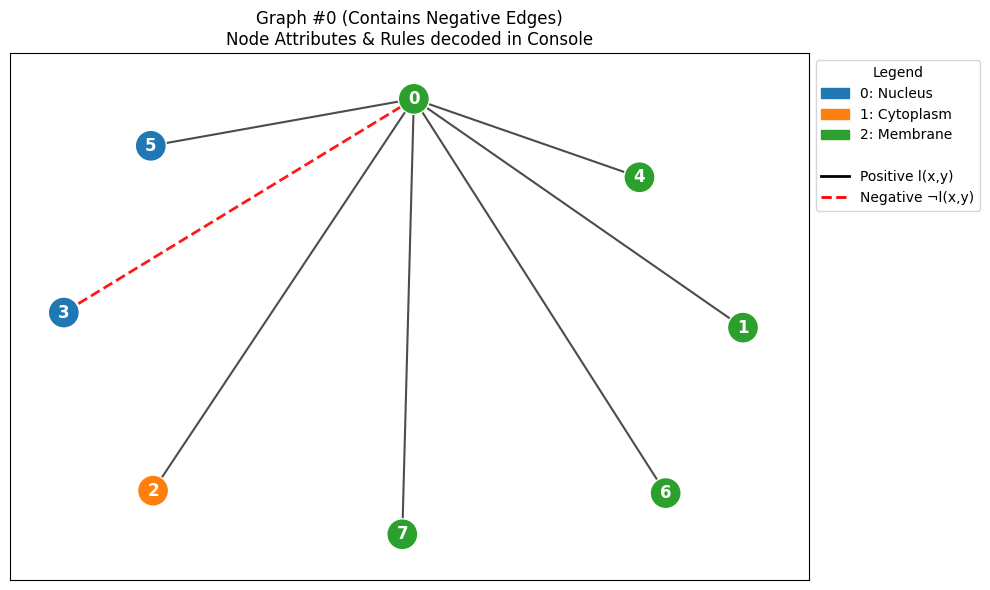


==================== Graph #4 ====================
Detected GAR+ Literals:
  n0.Loc == Unknown
  n1.Loc == Unknown
  n2.Loc == Nucleus
  ¬l(n0, n2)
  ¬l(n1, n2)


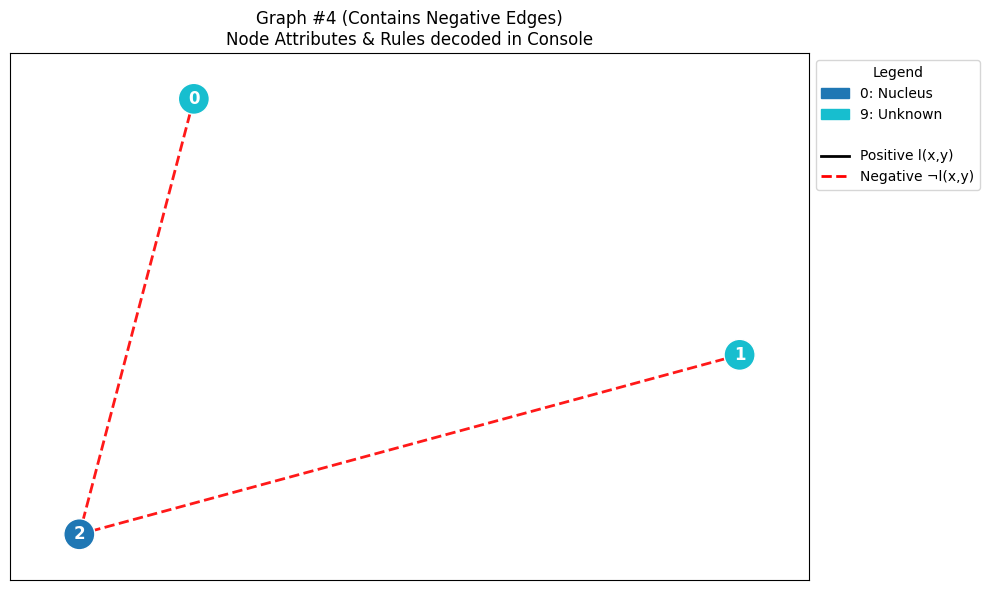


==================== Graph #5 ====================
Detected GAR+ Literals:
  n0.Loc == Membrane
  n1.Loc == Secreted
  n2.Loc == Membrane
  n3.Loc == Nucleus
  n4.Loc == Membrane
  n5.Loc == Nucleus
  n6.Loc == Membrane
  n7.Loc == Membrane
  n8.Loc == Cytoplasm
  l(n0, n2)
  M(n0, n2)
  l(n1, n2)
  l(n2, n3)
  l(n2, n4)
  M(n2, n4)
  l(n2, n5)
  l(n2, n6)
  M(n2, n6)
  l(n2, n7)
  M(n2, n7)
  ¬l(n2, n8)
  l(n3, n5)
  l(n3, n8)


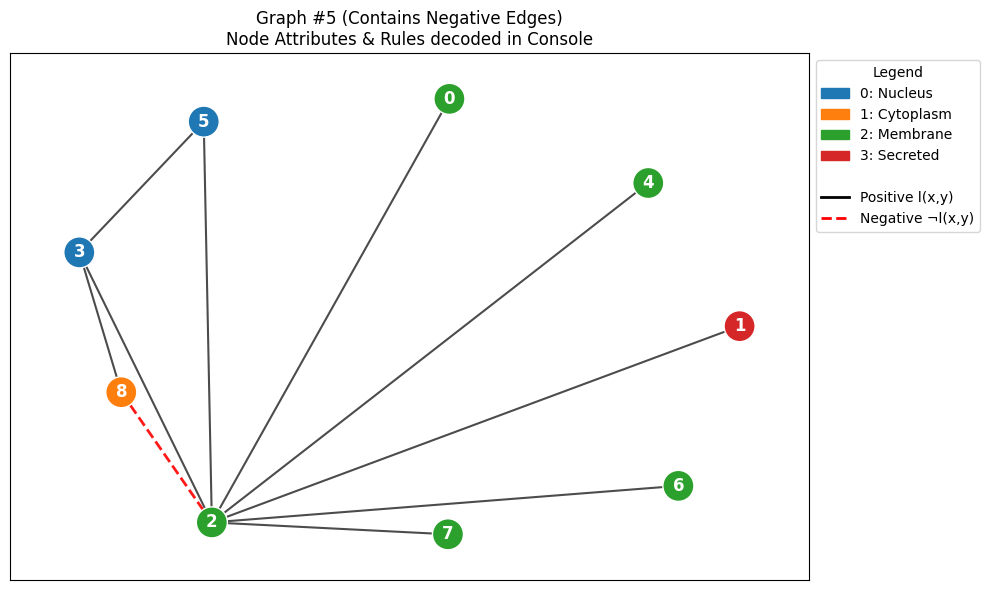


==================== Graph #6 ====================
Detected GAR+ Literals:
  n0.Loc == Nucleus
  n1.Loc == Unknown
  n2.Loc == Unknown
  n3.Loc == Nucleus
  n4.Loc == Nucleus
  n5.Loc == Nucleus
  n6.Loc == Unknown
  n7.Loc == Cytoplasm
  l(n0, n3)
  M(n0, n3)
  l(n0, n6)
  l(n1, n5)
  l(n1, n6)
  M(n1, n6)
  l(n2, n5)
  l(n2, n6)
  l(n3, n6)
  M(n3, n6)
  l(n4, n6)
  M(n4, n6)
  l(n5, n6)
  ¬l(n5, n7)
  M(n5, n7)
  ¬l(n6, n7)


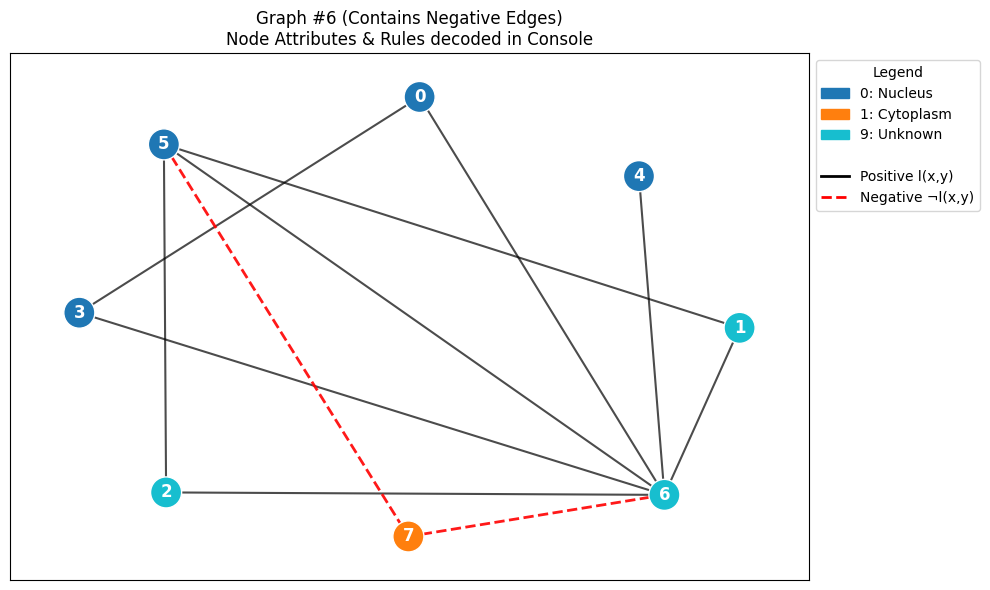


==================== Graph #12 ====================
Detected GAR+ Literals:
  n0.Loc == Membrane
  n1.Loc == Membrane
  n2.Loc == Membrane
  n3.Loc == Nucleus
  n4.Loc == Secreted
  n5.Loc == Membrane
  n6.Loc == Nucleus
  n7.Loc == Cytoplasm
  n8.Loc == Secreted
  ¬l(n0, n1)
  l(n1, n2)
  M(n1, n2)
  ¬l(n1, n3)
  l(n1, n4)
  l(n1, n5)
  l(n1, n6)
  l(n1, n7)
  l(n1, n8)
  l(n4, n6)


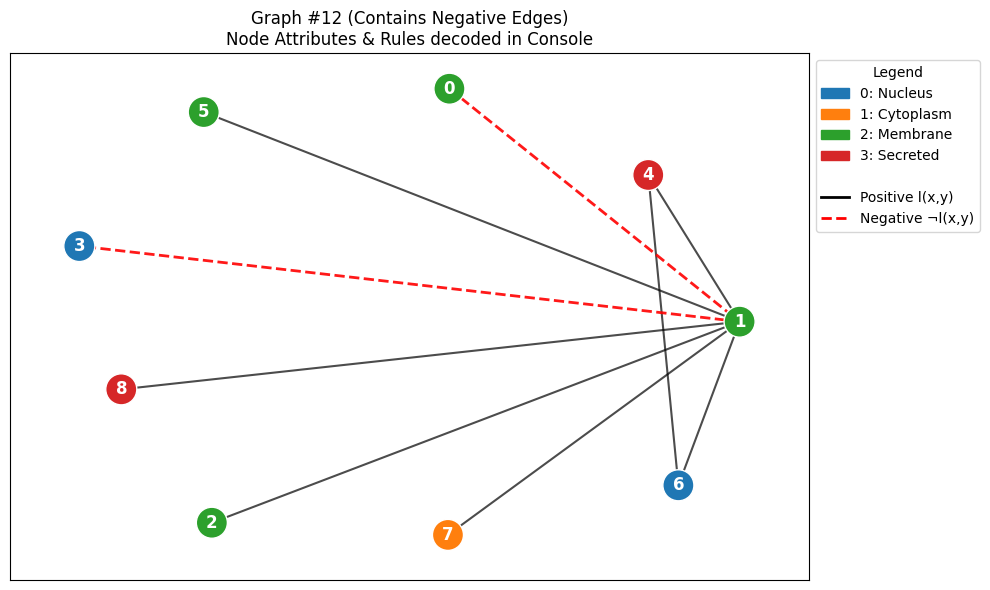


==================== Graph #18 ====================
Detected GAR+ Literals:
  n0.Loc == Membrane
  n1.Loc == Nucleus
  n2.Loc == Nucleus
  n3.Loc == Mitochondria
  n4.Loc == Membrane
  n5.Loc == Membrane
  n6.Loc == Nucleus
  n7.Loc == Nucleus
  n8.Loc == Membrane
  n9.Loc == Nucleus
  n10.Loc == Membrane
  n11.Loc == Membrane
  n12.Loc == Mitochondria
  n13.Loc == Membrane
  n14.Loc == Unknown
  ¬l(n0, n5)
  ¬l(n1, n5)
  ¬l(n2, n5)
  ¬l(n3, n5)
  ¬l(n4, n5)
  l(n5, n6)
  ¬l(n5, n7)
  ¬l(n5, n8)
  ¬l(n5, n9)
  ¬l(n5, n10)
  ¬l(n5, n11)
  ¬l(n5, n12)
  ¬l(n5, n13)
  ¬l(n5, n14)


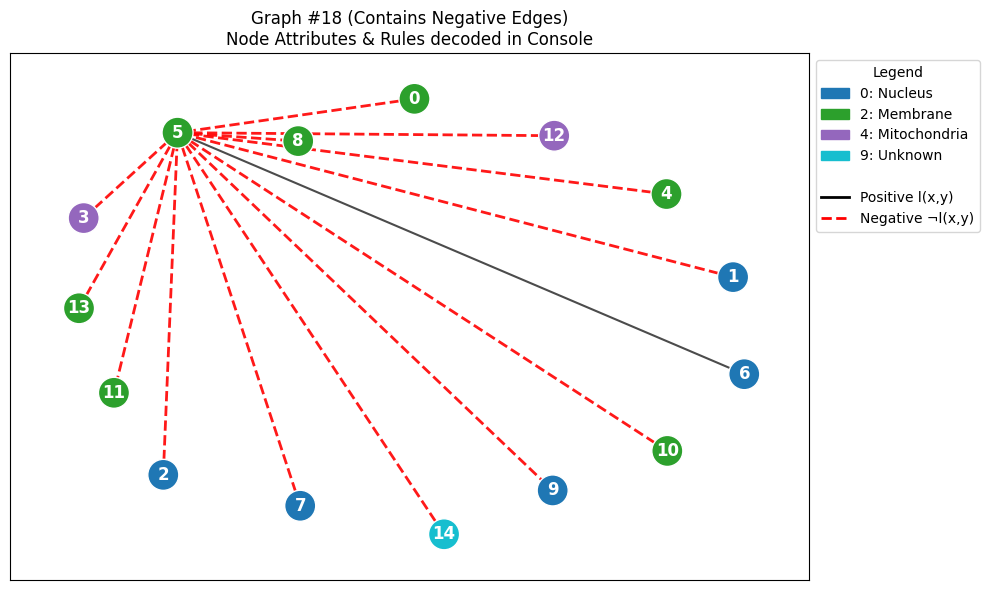


==================== Graph #29 ====================
Detected GAR+ Literals:
  n0.Loc == Cytoplasm
  n1.Loc == Cytoplasm
  n2.Loc == Membrane
  n3.Loc == Nucleus
  n4.Loc == Membrane
  n5.Loc == Membrane
  n6.Loc == Membrane
  n7.Loc == Membrane
  ¬l(n0, n5)
  ¬l(n0, n6)
  l(n1, n5)
  l(n2, n5)
  M(n2, n5)
  l(n3, n5)
  l(n4, n5)
  M(n4, n5)
  ¬l(n5, n6)
  l(n5, n7)
  M(n5, n7)


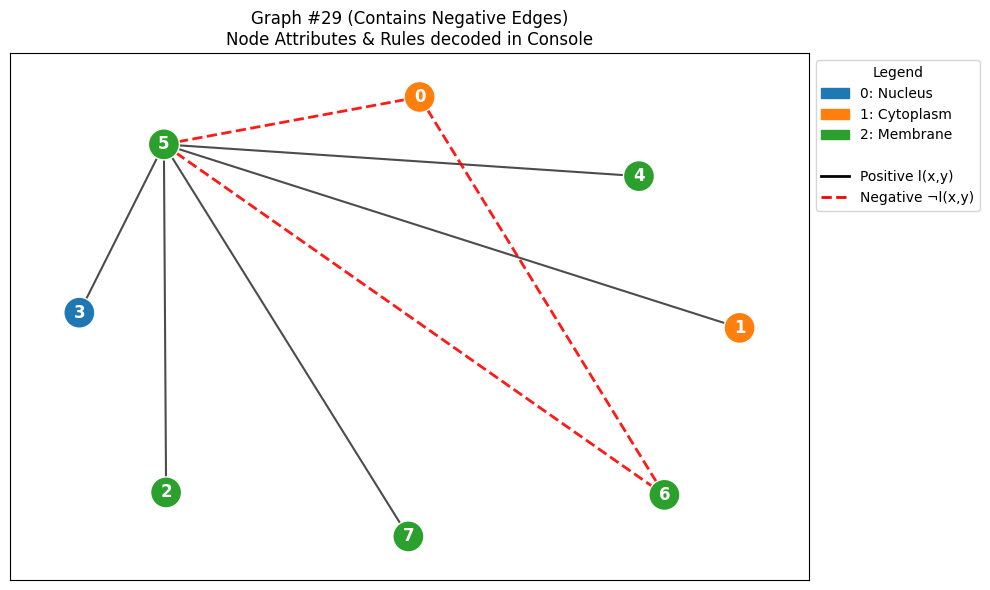


==================== Graph #31 ====================
Detected GAR+ Literals:
  n0.Loc == Nucleus
  n1.Loc == Nucleus
  n2.Loc == Nucleus
  n3.Loc == Nucleus
  n4.Loc == Nucleus
  n5.Loc == Cytoplasm
  n6.Loc == Nucleus
  l(n0, n1)
  l(n1, n2)
  M(n1, n2)
  l(n1, n3)
  l(n1, n4)
  M(n1, n4)
  ¬l(n1, n5)
  l(n1, n6)
  M(n1, n6)


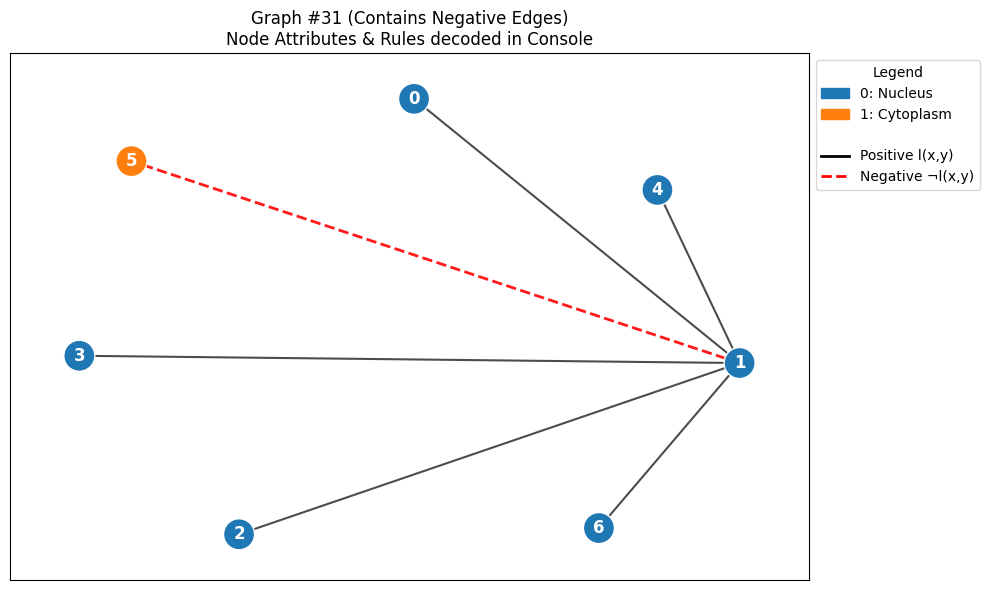


==================== Graph #36 ====================
Detected GAR+ Literals:
  n0.Loc == Cytoplasm
  n1.Loc == Secreted
  n2.Loc == Membrane
  l(n0, n1)
  ¬l(n1, n2)


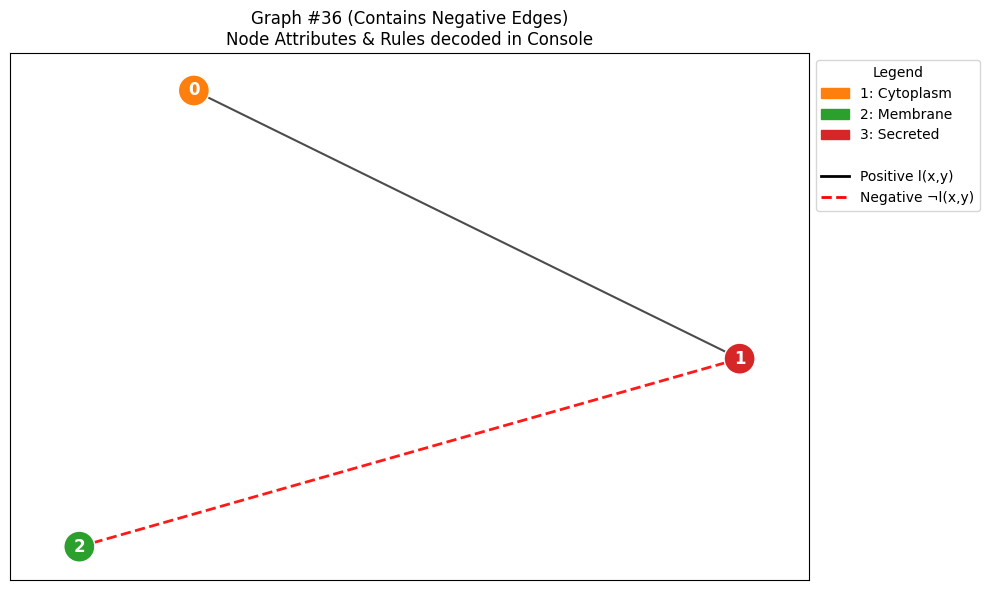


==================== Graph #37 ====================
Detected GAR+ Literals:
  n0.Loc == Nucleus
  n1.Loc == Cytoplasm
  n2.Loc == Nucleus
  n3.Loc == Golgi
  n4.Loc == Nucleus
  n5.Loc == Nucleus
  n6.Loc == Cytoplasm
  n7.Loc == ER
  n8.Loc == Unknown
  ¬l(n0, n1)
  l(n0, n5)
  l(n0, n7)
  l(n1, n2)
  l(n1, n3)
  l(n1, n4)
  l(n1, n5)
  l(n1, n6)
  l(n1, n7)
  l(n1, n8)
  l(n4, n5)
  l(n5, n7)


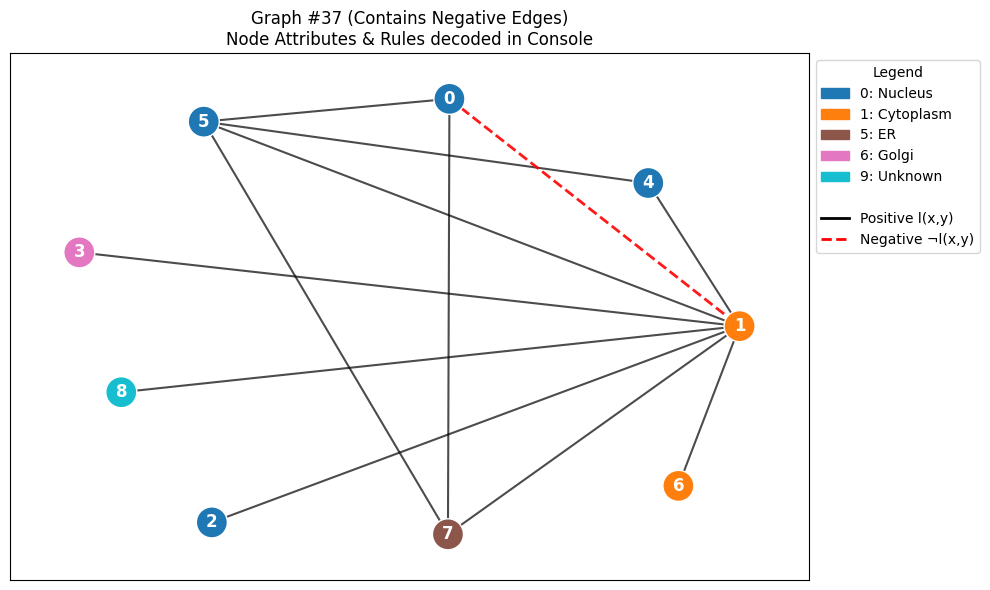


==================== Graph #41 ====================
Detected GAR+ Literals:
  n0.Loc == Unknown
  n1.Loc == Membrane
  n2.Loc == Membrane
  n3.Loc == Secreted
  n4.Loc == Membrane
  n5.Loc == Membrane
  n6.Loc == Membrane
  n7.Loc == Membrane
  n8.Loc == Membrane
  n9.Loc == Membrane
  ¬l(n0, n4)
  ¬l(n0, n5)
  l(n1, n5)
  M(n1, n5)
  ¬l(n2, n4)
  l(n2, n5)
  M(n2, n5)
  ¬l(n3, n4)
  l(n3, n5)
  M(n3, n5)
  ¬l(n4, n5)
  l(n5, n6)
  M(n5, n6)
  l(n5, n7)
  M(n5, n7)
  l(n5, n8)
  M(n5, n8)
  l(n5, n9)
  M(n5, n9)


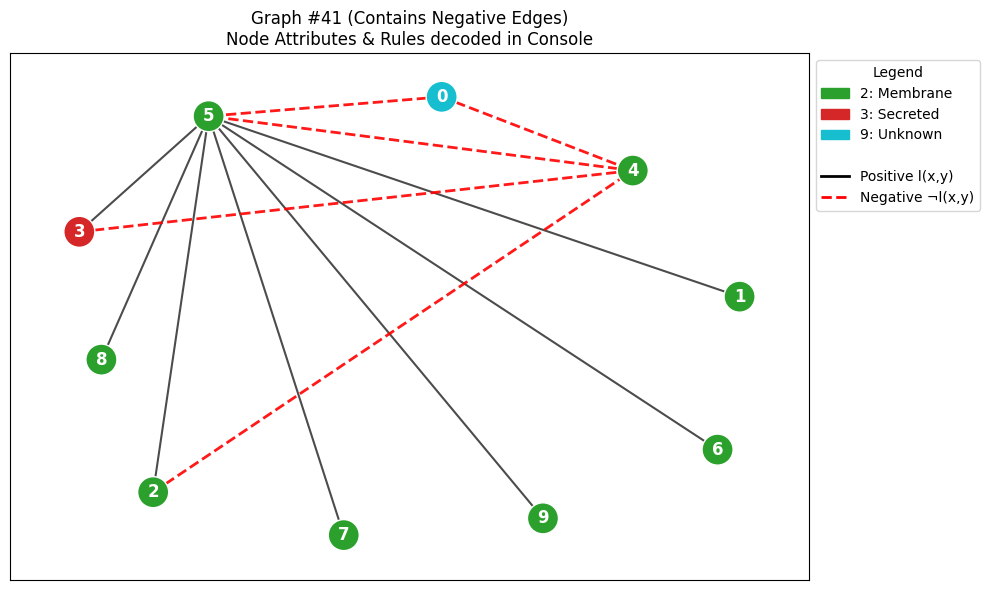


==================== Graph #45 ====================
Detected GAR+ Literals:
  n0.Loc == Nucleus
  n1.Loc == Cytoplasm
  n2.Loc == Nucleus
  n3.Loc == Unknown
  n4.Loc == Membrane
  n5.Loc == Nucleus
  n6.Loc == Nucleus
  n7.Loc == Nucleus
  n8.Loc == Nucleus
  n9.Loc == Nucleus
  n10.Loc == Nucleus
  l(n0, n8)
  l(n1, n8)
  M(n1, n8)
  l(n2, n7)
  l(n2, n8)
  l(n3, n4)
  l(n3, n8)
  l(n3, n10)
  ¬l(n4, n8)
  l(n4, n10)
  ¬l(n5, n6)
  ¬l(n5, n8)
  ¬l(n6, n8)
  l(n7, n8)
  l(n8, n9)
  l(n8, n10)


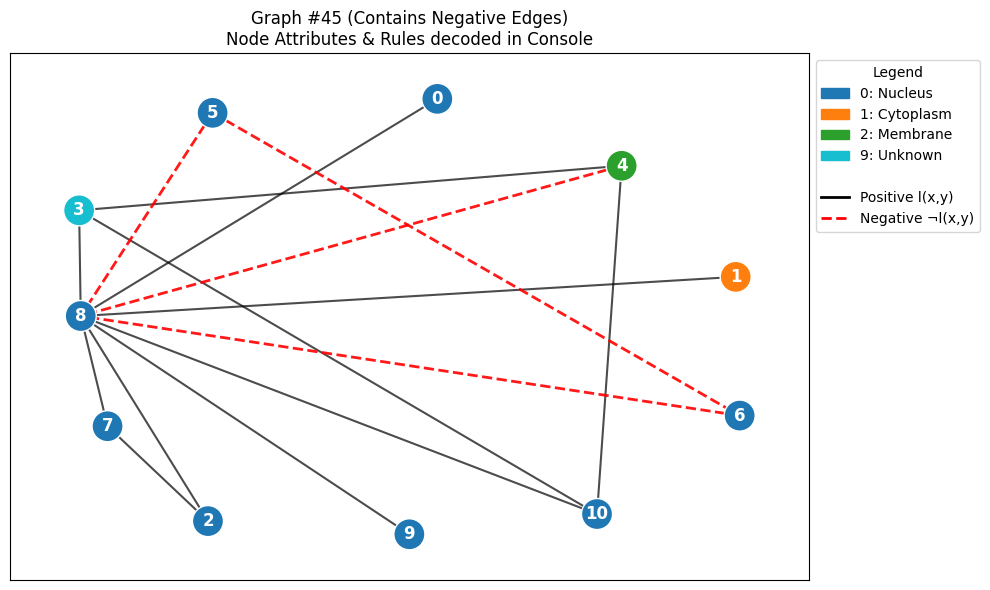


==================== Graph #52 ====================
Detected GAR+ Literals:
  n0.Loc == Nucleus
  n1.Loc == Nucleus
  n2.Loc == Nucleus
  n3.Loc == Nucleus
  n4.Loc == Nucleus
  n5.Loc == Nucleus
  n6.Loc == Nucleus
  n7.Loc == Secreted
  l(n0, n3)
  l(n1, n3)
  l(n2, n3)
  l(n3, n4)
  l(n3, n5)
  l(n3, n6)
  ¬l(n3, n7)


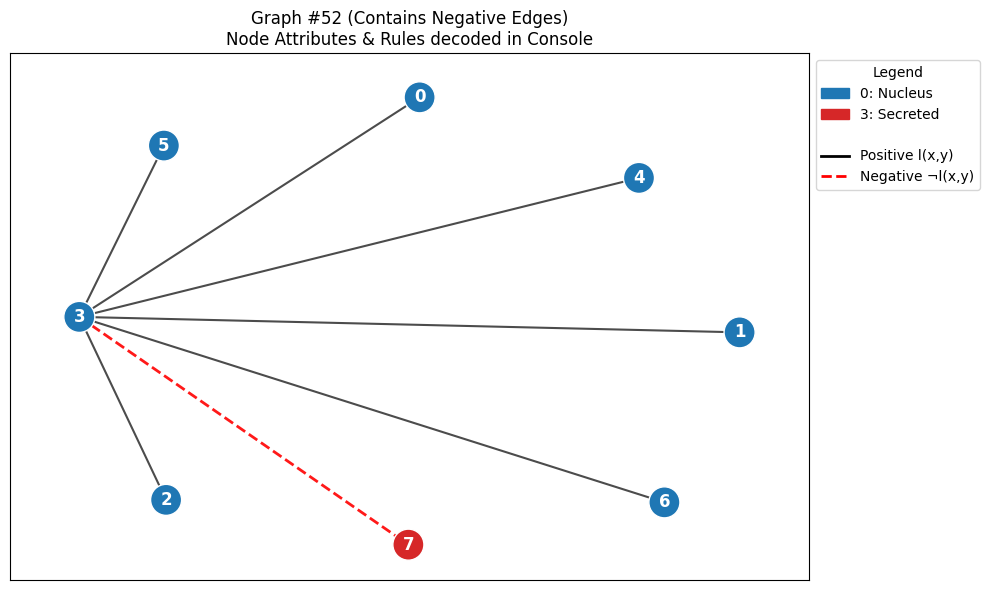


==================== Graph #53 ====================
Detected GAR+ Literals:
  n0.Loc == Mitochondria
  n1.Loc == Cytoplasm
  n2.Loc == Nucleus
  n3.Loc == Nucleus
  n4.Loc == Nucleus
  n5.Loc == Membrane
  n6.Loc == Membrane
  l(n0, n1)
  ¬l(n1, n2)
  ¬l(n1, n3)
  ¬l(n1, n4)
  ¬l(n1, n5)
  ¬l(n1, n6)


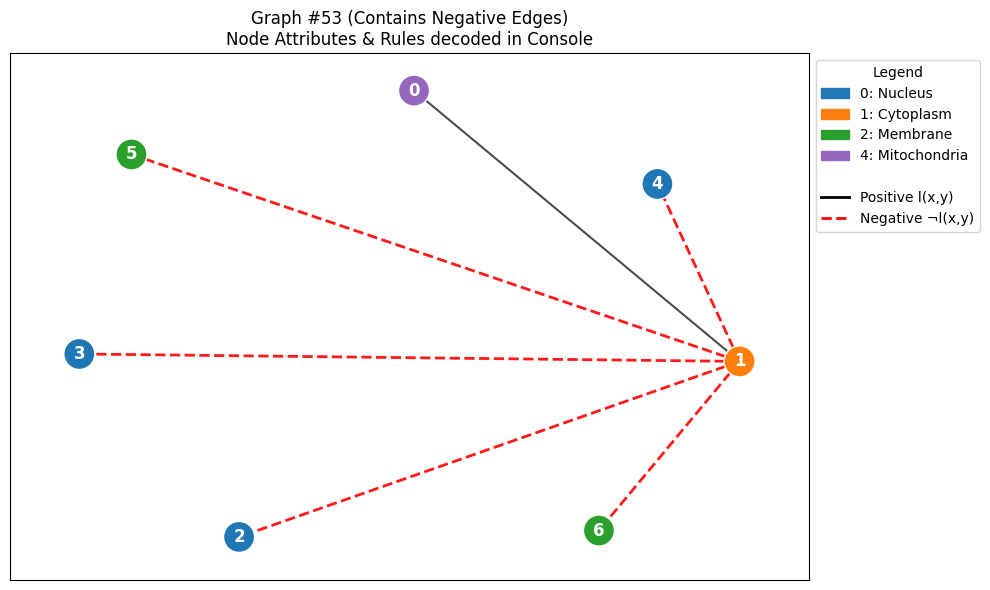


==================== Graph #54 ====================
Detected GAR+ Literals:
  n0.Loc == Membrane
  n1.Loc == Cytoplasm
  n2.Loc == Nucleus
  n3.Loc == Membrane
  n4.Loc == Nucleus
  n5.Loc == Membrane
  n6.Loc == Membrane
  n7.Loc == Nucleus
  n8.Loc == Nucleus
  n9.Loc == Membrane
  n10.Loc == Unknown
  n11.Loc == Mitochondria
  n12.Loc == Membrane
  n13.Loc == Membrane
  ¬l(n0, n1)
  l(n0, n2)
  l(n0, n3)
  l(n0, n4)
  l(n0, n5)
  l(n0, n6)
  l(n0, n7)
  l(n0, n8)
  M(n0, n8)
  l(n0, n9)
  l(n0, n10)
  l(n0, n11)
  l(n0, n12)
  l(n0, n13)
  l(n5, n7)
  l(n5, n9)
  M(n5, n9)
  l(n6, n9)


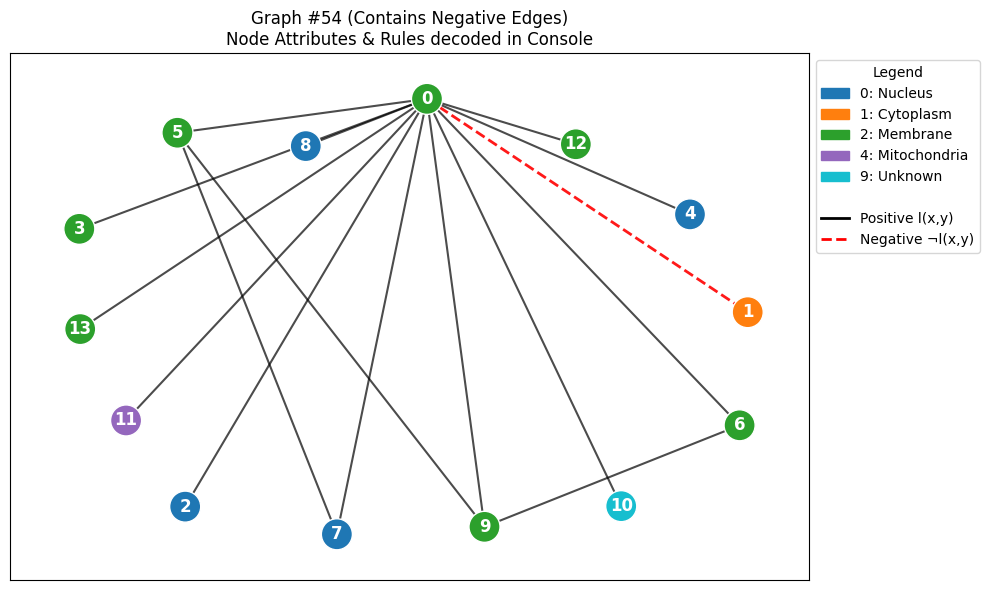


==================== Graph #55 ====================
Detected GAR+ Literals:
  n0.Loc == Secreted
  n1.Loc == Cytoplasm
  n2.Loc == Nucleus
  n3.Loc == Membrane
  n4.Loc == Membrane
  n5.Loc == Membrane
  n6.Loc == Unknown
  n7.Loc == Membrane
  n8.Loc == Nucleus
  n9.Loc == Membrane
  n10.Loc == Membrane
  n11.Loc == Unknown
  n12.Loc == Membrane
  n13.Loc == Membrane
  n14.Loc == Nucleus
  l(n0, n12)
  M(n0, n12)
  l(n1, n12)
  M(n1, n12)
  l(n2, n7)
  M(n2, n7)
  l(n2, n12)
  M(n2, n12)
  l(n2, n14)
  l(n3, n12)
  M(n3, n12)
  l(n4, n12)
  M(n4, n12)
  l(n5, n12)
  l(n5, n14)
  l(n6, n12)
  M(n6, n12)
  l(n7, n9)
  M(n7, n9)
  l(n7, n12)
  ¬l(n8, n12)
  l(n9, n12)
  M(n9, n12)
  l(n10, n12)
  M(n10, n12)
  l(n10, n14)
  M(n10, n14)
  l(n11, n12)
  M(n11, n12)
  l(n12, n13)
  M(n12, n13)
  l(n12, n14)


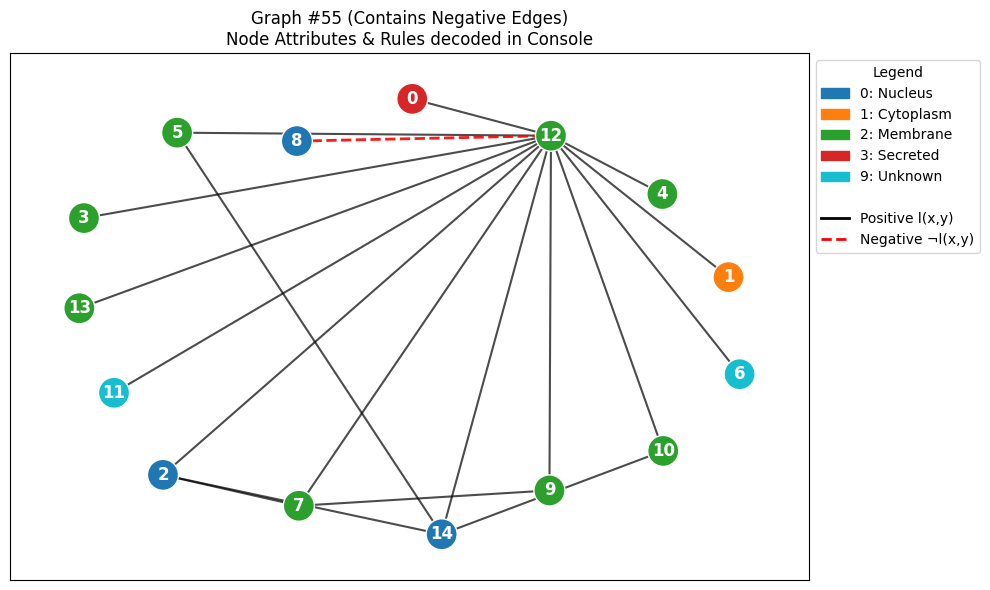


==================== Graph #56 ====================
Detected GAR+ Literals:
  n0.Loc == Nucleus
  n1.Loc == Nucleus
  n2.Loc == Membrane
  n3.Loc == Nucleus
  n4.Loc == Nucleus
  n5.Loc == Nucleus
  n6.Loc == Membrane
  n7.Loc == Unknown
  n8.Loc == Nucleus
  n9.Loc == Cytoplasm
  n10.Loc == Nucleus
  l(n0, n10)
  l(n1, n10)
  l(n2, n10)
  M(n2, n10)
  l(n3, n7)
  l(n3, n10)
  ¬l(n4, n7)
  ¬l(n4, n10)
  l(n5, n10)
  l(n6, n10)
  M(n6, n10)
  l(n7, n10)
  l(n8, n10)
  l(n9, n10)
  M(n9, n10)


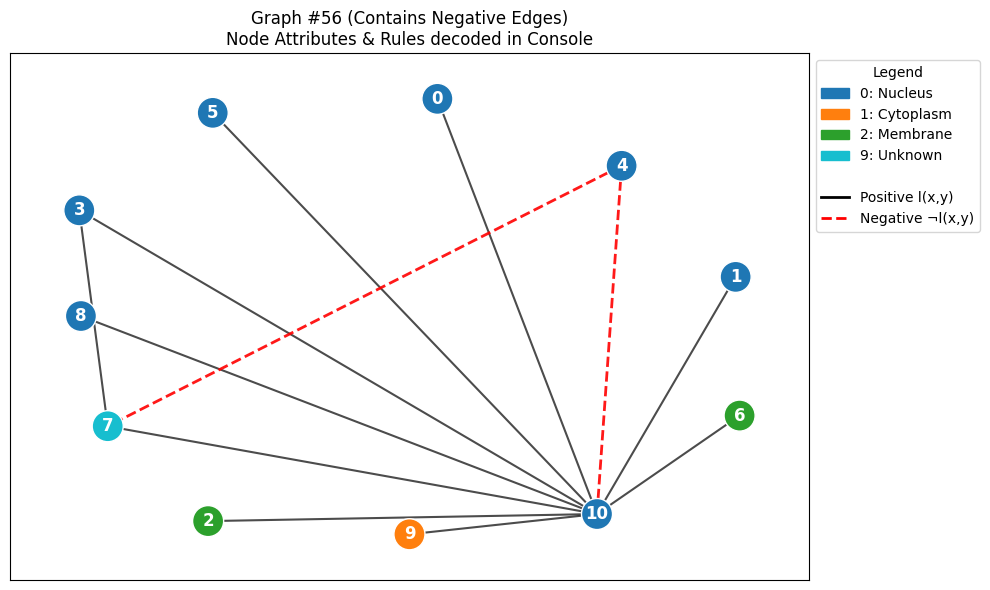


==================== Graph #57 ====================
Detected GAR+ Literals:
  n0.Loc == Nucleus
  n1.Loc == Nucleus
  n2.Loc == Nucleus
  n3.Loc == Unknown
  n4.Loc == Nucleus
  n5.Loc == Nucleus
  n6.Loc == Nucleus
  n7.Loc == Nucleus
  l(n0, n2)
  ¬l(n1, n2)
  l(n1, n4)
  l(n1, n5)
  l(n1, n6)
  l(n1, n7)
  l(n2, n3)
  l(n2, n4)
  l(n2, n5)
  ¬l(n2, n6)
  l(n2, n7)


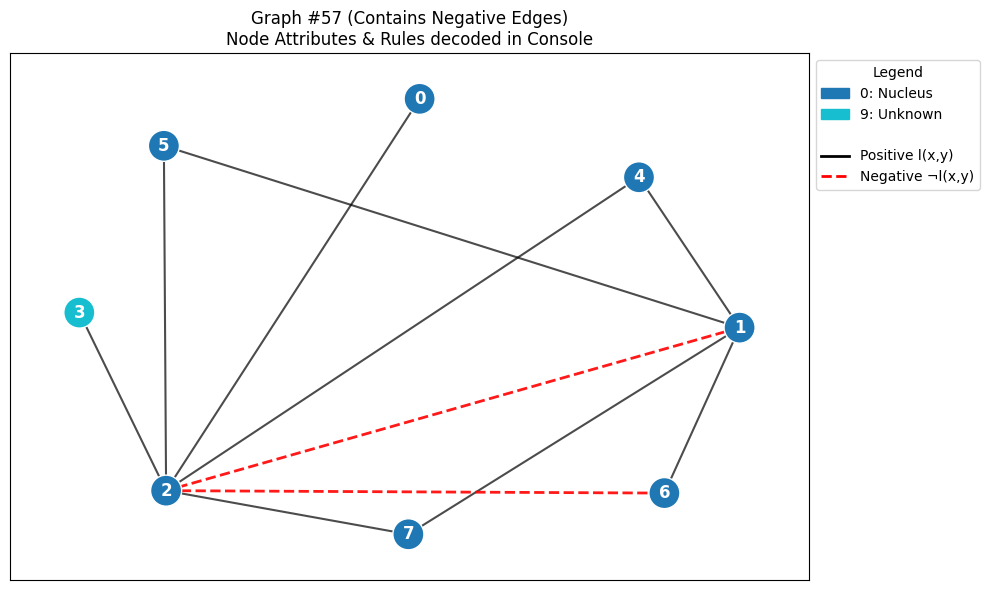


==================== Graph #64 ====================
Detected GAR+ Literals:
  n0.Loc == Membrane
  n1.Loc == Secreted
  n2.Loc == Membrane
  l(n0, n1)
  M(n0, n1)
  ¬l(n0, n2)


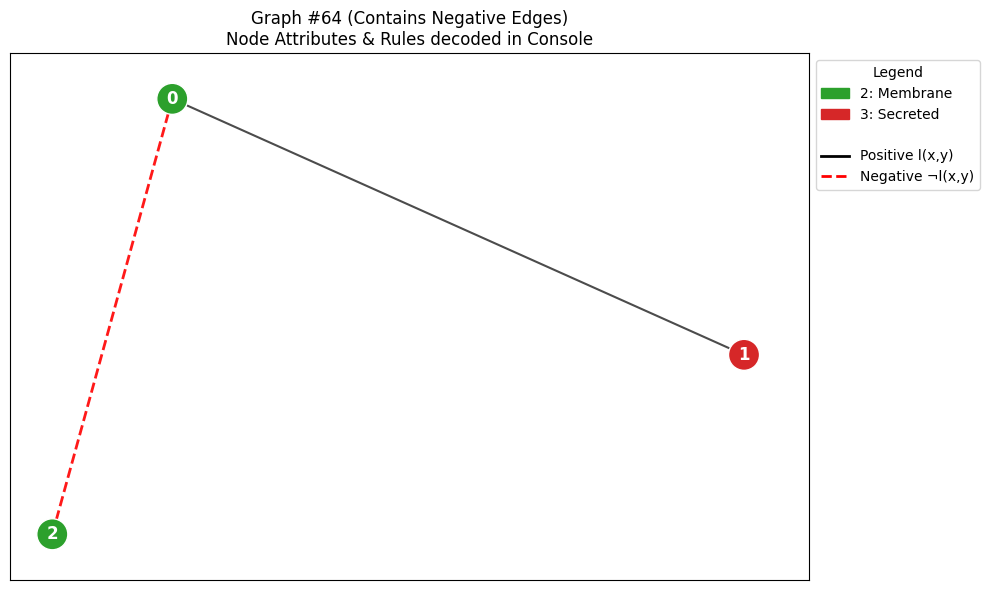


==================== Graph #68 ====================
Detected GAR+ Literals:
  n0.Loc == Cytoplasm
  n1.Loc == Membrane
  n2.Loc == Cytoplasm
  n3.Loc == Nucleus
  n4.Loc == Cytoplasm
  n5.Loc == Membrane
  l(n0, n4)
  l(n1, n4)
  l(n2, n4)
  ¬l(n3, n4)
  l(n4, n5)
  M(n4, n5)


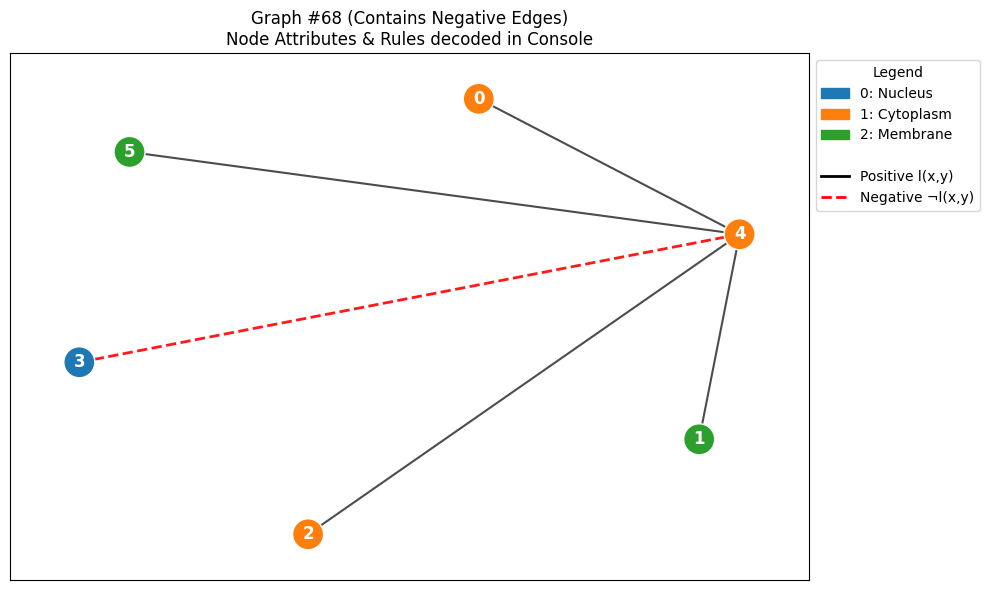


==================== Graph #70 ====================
Detected GAR+ Literals:
  n0.Loc == Unknown
  n1.Loc == Membrane
  n2.Loc == Membrane
  n3.Loc == Unknown
  n4.Loc == Membrane
  n5.Loc == Membrane
  n6.Loc == Membrane
  n7.Loc == Cytoplasm
  l(n0, n1)
  l(n0, n2)
  l(n0, n3)
  M(n0, n3)
  l(n0, n4)
  M(n0, n4)
  l(n0, n5)
  M(n0, n5)
  l(n0, n6)
  M(n0, n6)
  ¬l(n0, n7)


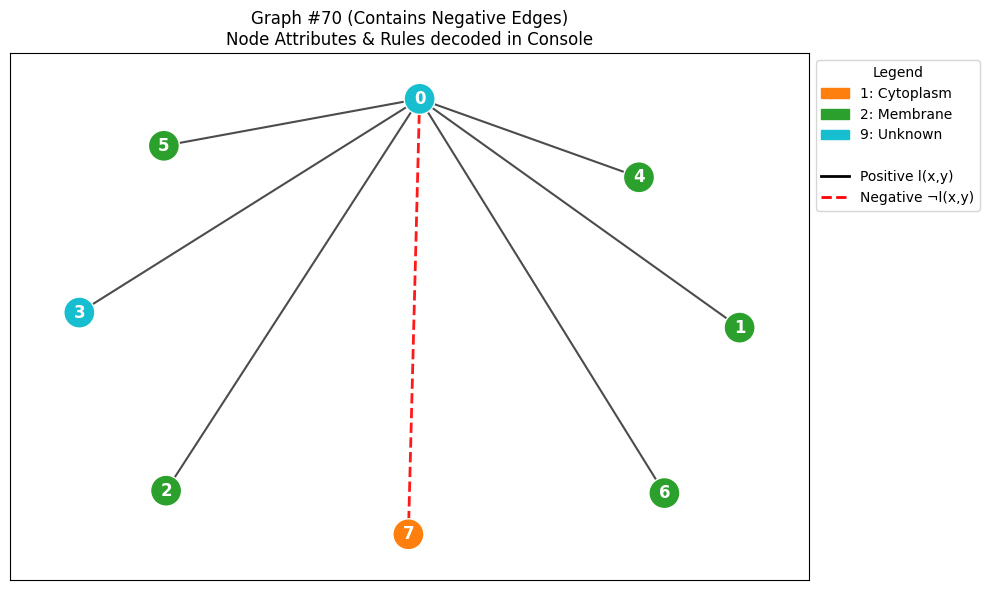


==================== Graph #73 ====================
Detected GAR+ Literals:
  n0.Loc == Membrane
  n1.Loc == Nucleus
  n2.Loc == Unknown
  n3.Loc == Unknown
  n4.Loc == Mitochondria
  n5.Loc == Cytoplasm
  ¬l(n0, n5)
  l(n1, n5)
  l(n2, n5)
  M(n2, n5)
  l(n3, n5)
  l(n4, n5)


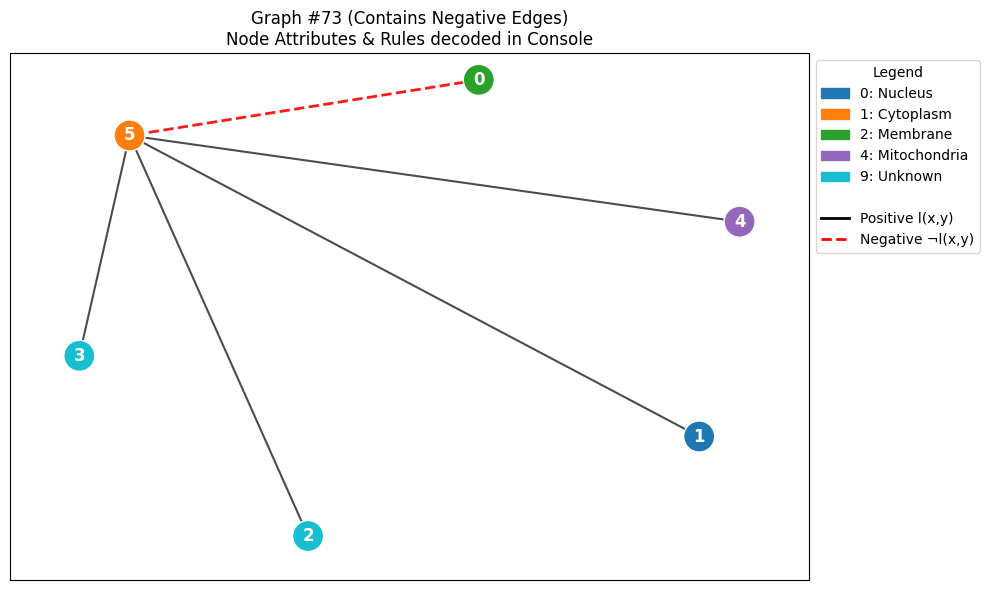


==================== Graph #74 ====================
Detected GAR+ Literals:
  n0.Loc == Unknown
  n1.Loc == Nucleus
  n2.Loc == Nucleus
  n3.Loc == Membrane
  n4.Loc == Membrane
  n5.Loc == Nucleus
  n6.Loc == Nucleus
  n7.Loc == Unknown
  n8.Loc == Nucleus
  n9.Loc == Nucleus
  n10.Loc == Nucleus
  n11.Loc == Nucleus
  l(n0, n2)
  M(n0, n2)
  l(n1, n2)
  l(n1, n8)
  l(n2, n3)
  l(n2, n4)
  M(n2, n4)
  l(n2, n5)
  l(n2, n6)
  M(n2, n6)
  l(n2, n7)
  M(n2, n7)
  ¬l(n2, n8)
  l(n2, n9)
  l(n2, n10)
  l(n2, n11)
  M(n2, n11)
  l(n5, n9)
  l(n8, n10)
  l(n9, n10)


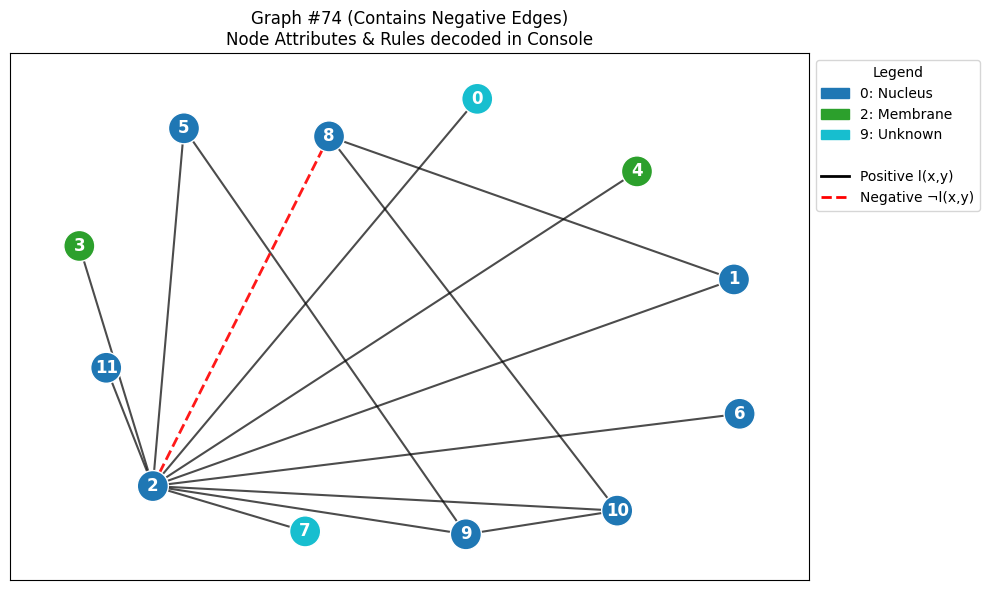


==================== Graph #87 ====================
Detected GAR+ Literals:
  n0.Loc == Membrane
  n1.Loc == Unknown
  n2.Loc == Nucleus
  n3.Loc == Membrane
  n4.Loc == Nucleus
  n5.Loc == Unknown
  n6.Loc == Unknown
  n7.Loc == Nucleus
  n8.Loc == Secreted
  l(n0, n2)
  ¬l(n1, n2)
  l(n1, n4)
  l(n2, n3)
  l(n2, n4)
  l(n2, n5)
  l(n2, n6)
  l(n2, n7)
  M(n2, n7)
  ¬l(n2, n8)


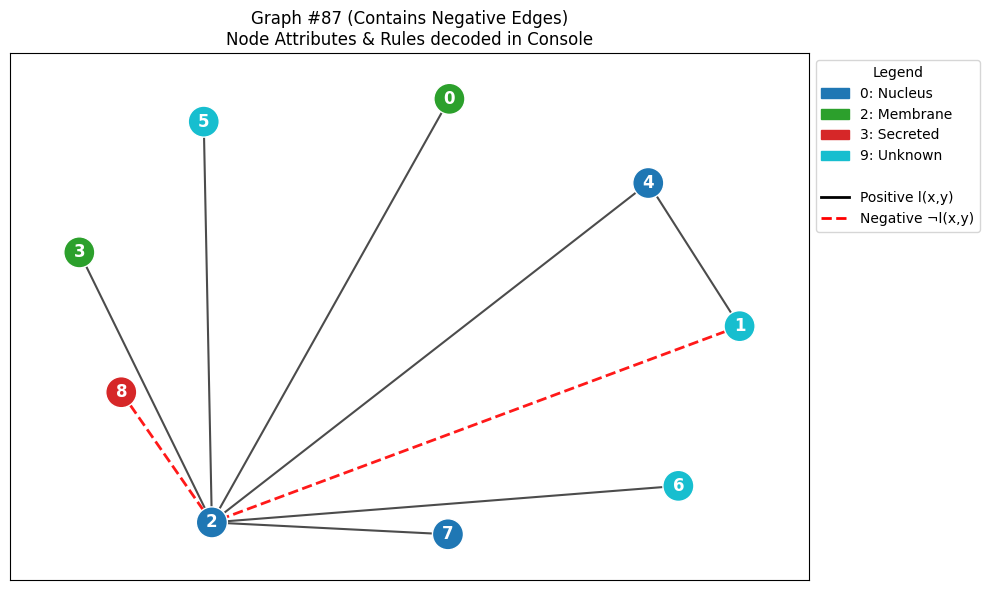


==================== Graph #92 ====================
Detected GAR+ Literals:
  n0.Loc == Membrane
  n1.Loc == Membrane
  n2.Loc == Membrane
  n3.Loc == Nucleus
  n4.Loc == Nucleus
  n5.Loc == Nucleus
  n6.Loc == Membrane
  n7.Loc == Membrane
  n8.Loc == Nucleus
  n9.Loc == Mitochondria
  l(n0, n1)
  M(n0, n1)
  l(n1, n2)
  M(n1, n2)
  l(n1, n3)
  l(n1, n4)
  l(n1, n5)
  ¬l(n1, n6)
  l(n1, n7)
  M(n1, n7)
  l(n1, n8)
  l(n1, n9)
  M(n1, n9)
  l(n3, n8)
  l(n4, n8)
  l(n7, n8)


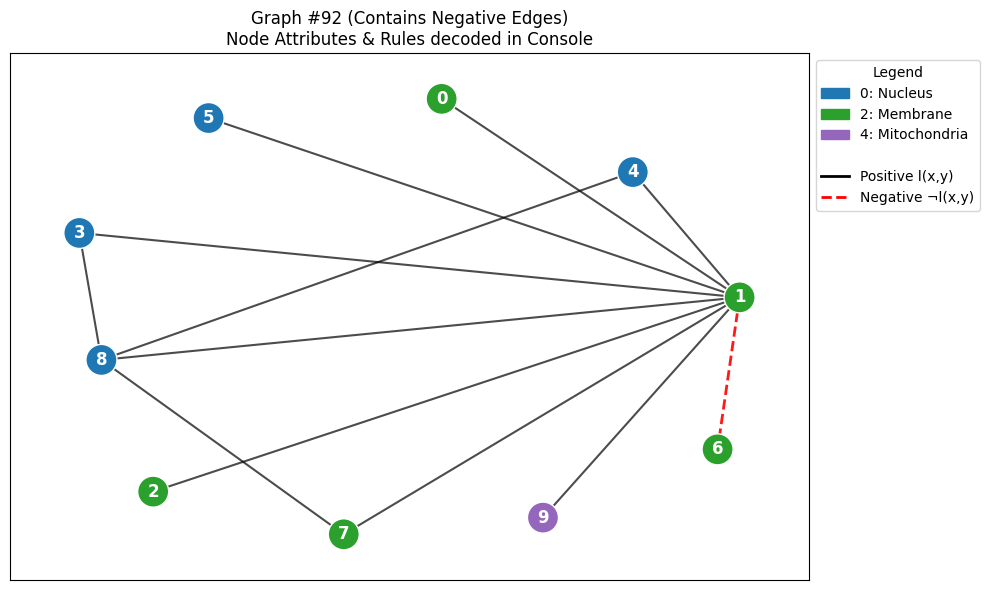


==================== Graph #99 ====================
Detected GAR+ Literals:
  n0.Loc == Nucleus
  n1.Loc == Nucleus
  n2.Loc == Membrane
  n3.Loc == Membrane
  n4.Loc == Membrane
  n5.Loc == Membrane
  n6.Loc == Membrane
  l(n0, n1)
  l(n1, n2)
  M(n1, n2)
  l(n1, n3)
  l(n1, n4)
  l(n1, n5)
  M(n1, n5)
  l(n1, n6)
  M(n1, n6)
  l(n2, n6)
  M(n2, n6)
  ¬l(n3, n4)
  ¬l(n4, n5)


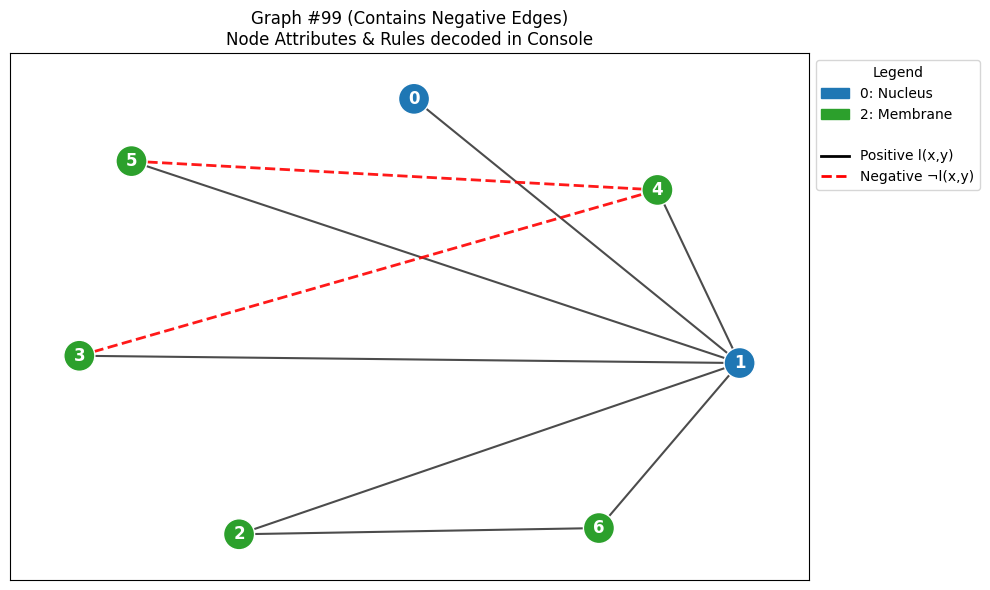

In [7]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import matplotlib.patches as mpatches
import os

# ==========================================
# 1. 配置与定义
# ==========================================

LOC_CATEGORIES = [
    "Nucleus",       # 0
    "Cytoplasm",     # 1
    "Membrane",      # 2
    "Secreted",      # 3
    "Mitochondria",  # 4
    "ER",            # 5
    "Golgi",         # 6
    "Lysosome",      # 7
    "Other",         # 8
    "Unknown"        # 9
]

# 颜色映射
COLOR_MAP = plt.cm.get_cmap('tab10', len(LOC_CATEGORIES))

# ==========================================
# 2. 规则解码器 (GAR+ Rule Decoder)
# ==========================================

def decode_gar_rules(X, E):
    """
    将图数据 (X, E) 解码为 GAR+ 规则集合 (Literals)。
    """
    literals = []
    num_nodes = len(X)
    
    # --- A. 解码节点谓词 ---
    for i in range(num_nodes):
        cat_idx = X[i]
        if cat_idx >= len(LOC_CATEGORIES): cat_idx = 8
        cat_name = LOC_CATEGORIES[cat_idx]
        rule = f"n{i}.Loc == {cat_name}"
        literals.append(rule)

    # --- B. 解码边谓词 ---
    rows, cols = E.shape
    for u in range(rows):
        for v in range(u + 1, cols):
            val = E[u][v]
            if val == 0: continue
            
            # 1: Pos+Low, 2: Pos+High, 3: Neg+Low, 4: Neg+High
            
            # 拓扑谓词
            if val in [1, 2]:
                topo_rule = f"l(n{u}, n{v})"
            else: # 3, 4
                topo_rule = f"¬l(n{u}, n{v})"
            literals.append(topo_rule)
            
            # 置信度谓词 (仅高置信度)
            if val in [2, 4]:
                ml_rule = f"M(n{u}, n{v})"
                literals.append(ml_rule)
            
    return literals

# ==========================================
# 3. 文件解析器
# ==========================================

def parse_graphs_from_txt(file_path):
    if not os.path.exists(file_path):
        print(f"Error: 文件 {file_path} 不存在")
        return []

    graphs = []
    current_x = None
    
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if not line:
            i += 1
            continue
            
        if line.startswith("X:"):
            if i + 1 < len(lines):
                try:
                    current_x = np.array([int(v) for v in lines[i+1].strip().split()])
                    i += 1
                except ValueError: pass
            
        elif line.startswith("E:") and current_x is not None:
            num_nodes = len(current_x)
            e_matrix = []
            valid_matrix = True
            for r in range(num_nodes):
                if i + 1 + r < len(lines):
                    try:
                        row_vals = [int(v) for v in lines[i + 1 + r].strip().split()]
                        if len(row_vals) == num_nodes: e_matrix.append(row_vals)
                        else: valid_matrix = False
                    except: valid_matrix = False
                else: valid_matrix = False
            
            if valid_matrix and len(e_matrix) == num_nodes:
                graphs.append((current_x, np.array(e_matrix)))
                i += num_nodes 
                current_x = None 
        i += 1
    return graphs

# ==========================================
# 4. 可视化与输出函数
# ==========================================

def visualize_graph(x, e, graph_id=0):
    num_nodes = len(x)
    
    # 1. 预处理边，检查是否有负边
    pos_edges = []
    neg_edges = []
    rows, cols = e.shape
    for i in range(rows):
        for j in range(i + 1, cols):
            val = e[i][j]
            if val == 0: continue
            if val in [1, 2]: pos_edges.append((i, j))
            elif val in [3, 4]: neg_edges.append((i, j))

    # ★★★ 过滤逻辑：只显示包含负边的图 ★★★
    if len(neg_edges) == 0:
        return 

    # 2. 生成规则文本
    rules = decode_gar_rules(x, e)
    
    print(f"\n{'='*20} Graph #{graph_id} {'='*20}")
    print("Detected GAR+ Literals:")
    for r in rules:
        print(f"  {r}")
    print("="*50)

    # 3. 绘图
    G = nx.Graph()
    node_colors = []
    categories_present = set()
    
    for i in range(num_nodes):
        cat_idx = x[i]
        if cat_idx >= len(LOC_CATEGORIES): cat_idx = 8 
        cat_name = LOC_CATEGORIES[cat_idx]
        categories_present.add(cat_idx)
        
        G.add_node(i, category=cat_name)
        node_colors.append(COLOR_MAP(cat_idx))
        
    plt.figure(figsize=(10, 6)) # 稍微加宽一点，方便看
    
    pos = nx.spring_layout(G, seed=42, k=0.6) 
    
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500, edgecolors='white')
    nx.draw_networkx_labels(G, pos, font_color='white', font_weight='bold')
    
    if pos_edges:
        nx.draw_networkx_edges(G, pos, edgelist=pos_edges, 
                            edge_color='black', style='solid', width=1.5, alpha=0.7)
    if neg_edges:
        nx.draw_networkx_edges(G, pos, edgelist=neg_edges, 
                            edge_color='red', style='dashed', width=2.0, alpha=0.9) # 负边用红色虚线更醒目
    
    # 图例
    legend_handles = []
    for cat_idx in sorted(list(categories_present)):
        patch = mpatches.Patch(color=COLOR_MAP(cat_idx), label=f"{cat_idx}: {LOC_CATEGORIES[cat_idx]}")
        legend_handles.append(patch)
    
    legend_handles.append(mpatches.Patch(color='none', label=' '))
    legend_handles.append(plt.Line2D([0], [0], color='black', lw=2, linestyle='-', label='Positive l(x,y)'))
    legend_handles.append(plt.Line2D([0], [0], color='red', lw=2, linestyle='--', label='Negative ¬l(x,y)'))

    plt.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
    
    # 在图标题下方显示前 5 条规则作为摘要
    rule_summary = "\n".join(rules[:5])
    if len(rules) > 5: rule_summary += "\n..."
    
    plt.title(f"Graph #{graph_id} (Contains Negative Edges)\nNode Attributes & Rules decoded in Console")
    plt.tight_layout()
    plt.show()

# ==========================================
# 5. 主程序
# ==========================================

# 请确保此路径是正确的
FILE_PATH = "/home/yyyy/codework/GARplus/DiGress/outputs/2025-12-15/19-53-11-ppi_gar/generated_samples1.txt"

print(f"Reading from {FILE_PATH}...")
parsed_graphs = parse_graphs_from_txt(FILE_PATH)
print(f"Found {len(parsed_graphs)} total graphs.")
print("Filtering for graphs with NEGATIVE edges to visualize and decode...\n")

for idx, (x, e) in enumerate(parsed_graphs):
    visualize_graph(x, e, graph_id=idx)

# Support and confidence computation for PPI on training data

In [6]:
import networkx as nx
import time
import signal
import matplotlib.pyplot as plt
from networkx.algorithms.isomorphism import GraphMatcher
import os
import traceback
import sys
from collections import Counter

# ================= 配置区 =================
MATCH_LIMIT =10000
TIME_LIMIT = 5

TARGET_FILE = "/home/yyyy/codework/GARplus/DiGress/outputs/2025-12-15/19-53-11-ppi_gar/generated_samples1.txt"
RAW_DATA_FILE = "/home/yyyy/codework/GARplus/DiGress/outputs/2025-12-15/19-53-11-ppi_gar/train_graphs_ground_truth.txt" 

# GAR+ 编码
NEGATIVE_LABELS = [3, 4]

# ★★★ 新增：开关配置 ★★★
ENABLE_NODE_MATCH = True  # True: 必须节点类型也相同; False: 只看拓扑结构
# =========================================

class TimeoutException(Exception): pass
def timeout_handler(signum, frame): raise TimeoutException()
signal.signal(signal.SIGALRM, timeout_handler)

# ----------------------------------------------
# 1. 匹配逻辑
# ----------------------------------------------
def edge_match(d1, d2):
    return d1.get('label') == d2.get('label')

def node_match_fn(n1, n2):
    """ 比较两个节点的类别 (X特征) """
    # 假设解析时把类别存为了 'label' 或 'cat'
    # 注意：networkx 默认用 'label' 做图同构的节点匹配吗？不是，需要显式指定函数
    return n1.get('cat') == n2.get('cat')

# ----------------------------------------------
# 2. 解析逻辑 (需增强以读取 X)
# ----------------------------------------------
def parse_graph_txt(filepath):
    """ 解析 TXT，返回 [(x_list, edge_matrix), ...] """
    graphs = []
    if not os.path.exists(filepath): return []
    
    with open(filepath, "r") as f: lines = f.readlines()
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if line.startswith("N="):
            try:
                n = int(line.split("=")[1])
                i += 1
                
                # 读取 X
                while i < len(lines) and not lines[i].strip().startswith("X:"): i += 1
                if i < len(lines): i += 1 # 跳过 'X:' 行
                
                x_list = []
                if i < len(lines):
                    x_str = lines[i].strip()
                    x_list = list(map(int, x_str.split()))
                    i += 1
                
                # 读取 E
                while i < len(lines) and not lines[i].strip().startswith("E:"): i += 1
                
                edge_matrix = []
                if i < len(lines):
                    i += 1
                    for _ in range(n):
                        if i >= len(lines): break
                        row_vals = list(map(int, lines[i].strip().replace(',', ' ').split()))
                        edge_matrix.append(row_vals)
                        i += 1
                        
                    if len(edge_matrix) == n and len(x_list) == n:
                        graphs.append((x_list, edge_matrix))
            except: i += 1
        else:
            i += 1
    return graphs

def to_nx_graph(x_list, edge_matrix):
    """ 将解析出的数据转为 NX Graph (包含节点属性) """
    n = len(edge_matrix)
    G = nx.Graph()
    
    # 添加节点及属性
    for i in range(n):
        G.add_node(i, cat=x_list[i]) # 存为 'cat' 属性
        
    # 添加边
    for i in range(n):
        for j in range(i + 1, n):
            val = edge_matrix[i][j]
            if val != 0: 
                G.add_edge(i, j, label=val)
    return G

def load_digress_as_big_graph_undirected(filepath):
    BigG = nx.Graph()
    if not os.path.exists(filepath):
        print(f"[Error] File not found: {filepath}")
        return BigG

    print(f"Parsing BigGraph from: {filepath} ...")
    graphs_data = parse_graph_txt(filepath)
    
    node_offset = 0
    total_edges = 0

    for x_list, mat in graphs_data:
        n = len(mat)
        
        # 添加节点 (带 Offset 和 Attribute)
        for i in range(n):
            BigG.add_node(i + node_offset, cat=x_list[i])

        # 添加边
        for i in range(n):
            for j in range(i + 1, n):
                val = mat[i][j]
                if val != 0:
                    u = i + node_offset
                    v = j + node_offset
                    if BigG.has_edge(u, v):
                        BigG[u][v]['label'] = max(BigG[u][v]['label'], val)
                    else:
                        BigG.add_edge(u, v, label=val)
                        total_edges += 1
        node_offset += n

    print(f"BigGraph Constructed. Nodes: {BigG.number_of_nodes()}, Edges: {BigG.number_of_edges()}")
    return BigG

# ----------------------------------------------
# 3. 计算逻辑
# ----------------------------------------------
def compute_structural_confidence(subG, bigG, match_limit, time_limit, use_node_match=False):
    edges_to_test = list(subG.edges(data=True))
    if not edges_to_test: return [] 

    results = []
    target_candidates = [
        (u, v) for u, v, d in edges_to_test 
        if d.get('label') in NEGATIVE_LABELS
    ]
    if not target_candidates:
        target_candidates = [(u, v) for u, v, d in edges_to_test][:3]

    # 根据开关决定是否传入 node_match 函数
    nm_func = node_match_fn if use_node_match else None

    for target_u, target_v in target_candidates:
        original_label = subG[target_u][target_v]['label']
        premiseG = subG.copy()
        premiseG.remove_edge(target_u, target_v)
        
        if premiseG.number_of_edges() == 0: continue

        GM = GraphMatcher(bigG, premiseG, node_match=nm_func, edge_match=edge_match)
        
        supp_premise = 0
        supp_negative = 0
        # 0: 无边, 1/2: 正边, 3/4: 负边
        label_dist = Counter()
        signal.alarm(time_limit)
        status = "Finished"
        
        try:
            for mapping in GM.subgraph_isomorphisms_iter():
                # --- 映射修复 ---
                valid_mapping = None
                if (target_u in mapping) and (target_v in mapping): valid_mapping = mapping
                else:
                    inv_map = {v: k for k, v in mapping.items()}
                    if (target_u in inv_map) and (target_v in inv_map): valid_mapping = inv_map
                
                if valid_mapping is None: continue
                # ----------------
                
                supp_premise += 1
                real_u = valid_mapping[target_u]
                real_v = valid_mapping[target_v]

                real_label = 0 # 默认为 0 (无边)
                if bigG.has_edge(real_u, real_v):
                    edge_data = bigG.get_edge_data(real_u, real_v)
                    real_label = edge_data.get('label', 0)
                
                # 更新计数器
                label_dist[real_label] += 1

                # 仍然统计 supp_negative 用于计算 Conf
                if real_label in NEGATIVE_LABELS:
                    supp_negative += 1
                
                if supp_premise >= match_limit:
                    status = "Limit"
                    break
            signal.alarm(0)

        except TimeoutException:
            status = "TimeOut"
        except Exception as e:
            signal.alarm(0)
            status = "Error"
            continue

        if supp_premise > 0:
            confidence = supp_negative / supp_premise
            # 将 Counter 转为排序后的字典字符串，方便查看
            dist_str = str(dict(sorted(label_dist.items())))
            
            results.append({
                'target_edge': (target_u, target_v),
                'original_label': original_label,
                'confidence': confidence,
                'support_negative': supp_negative,
                'support_shape': supp_premise,
                'label_dist': dist_str, # <--- 存入结果
                'status': status
            })
            
    return results

# ----------------------------------------------
# 4. 主程序
# ----------------------------------------------
# ----------------------------------------------
if __name__ == "__main__":
    print(f"Node Matching Enabled: {ENABLE_NODE_MATCH}")
    print(f"Strategy: Only check Largest Connected Component (LCC)")
    
    bigG = load_digress_as_big_graph_undirected(RAW_DATA_FILE)
    if bigG.number_of_nodes() == 0:
        print("EXITING: BigGraph is empty.")
        exit()

    graphs_data = parse_graph_txt(TARGET_FILE)
    
    # ★★★ 修改表头：增加 TruthDist 列，且留宽一点 ★★★
    print(f"\n{'ID':<4} | {'Type':<4} | {'Conf':<7} | {'SuppNeg':<7} | {'SuppShape':<9} | {'TruthDist (0=NoEdge)':<30} | {'Status'}")
    print("-" * 100)
    
    cnt_graphs_with_neg = 0
    
    for idx, (x_list, edge_mat) in enumerate(graphs_data):
        full_G = to_nx_graph(x_list, edge_mat)
        
        # 统计整图是否有负边 (为了计数)
        has_neg_anywhere = any(d.get('label') in NEGATIVE_LABELS for _,_,d in full_G.edges(data=True))
        if has_neg_anywhere:
            cnt_graphs_with_neg += 1
        
        # =========================================================
        # ★★★ 修改核心：提取最大连通分量 (LCC) ★★★
        # =========================================================
        if full_G.number_of_nodes() == 0:
            continue
            
        # 1. 获取所有连通分量 (generator -> list)
        comps = list(nx.connected_components(full_G))
        
        # 2. 找到包含节点数最多的那个集合
        largest_comp_nodes = max(comps, key=len)
        
        # 3. 创建子图
        lcc_G = full_G.subgraph(largest_comp_nodes).copy()
        
        # 4. 只有当 LCC 至少有 1 条边时才处理 (孤立点没有拓扑意义)
        if lcc_G.number_of_edges() < 1:
            continue
            
        # 5. 放入列表，只处理这一个
        valid_components = [lcc_G]
        # =========================================================

        for sub_idx, subG in enumerate(valid_components):
            # 检查 LCC 内部是否有负边
            has_negative_edge = False
            for u, v, d in subG.edges(data=True):
                if d.get('label') in NEGATIVE_LABELS:
                    has_negative_edge = True
                    break
            
            # 如果 LCC 里没有负边，就跳过 (哪怕其他小碎片里有，也不管了)
            if not has_negative_edge: continue
            
            metrics = compute_structural_confidence(
                subG, bigG, MATCH_LIMIT, TIME_LIMIT, 
                use_node_match=ENABLE_NODE_MATCH
            )
            
            if not metrics: continue
            
            best_m = max(metrics, key=lambda x: x['confidence'])
            print(f"{idx:<4} | {best_m['original_label']:<4} | {best_m['confidence']:.4f}  | {best_m['support_negative']:<7} | {best_m['support_shape']:<9} | {best_m['label_dist']:<30} | {best_m['status']}")
            
    print(f"\nTotal graphs containing negative edges (Anywhere): {cnt_graphs_with_neg}")

Node Matching Enabled: True
Strategy: Only check Largest Connected Component (LCC)
Parsing BigGraph from: /home/yyyy/codework/GARplus/DiGress/outputs/2025-12-15/19-53-11-ppi_gar/train_graphs_ground_truth.txt ...
BigGraph Constructed. Nodes: 17755, Edges: 23562

ID   | Type | Conf    | SuppNeg | SuppShape | TruthDist (0=NoEdge)           | Status
----------------------------------------------------------------------------------------------------
0    | 3    | 0.0000  | 0       | 10000     | {0: 10000}                     | Limit
4    | 3    | 0.0000  | 0       | 5271      | {0: 5271}                      | TimeOut
31   | 3    | 0.0000  | 0       | 10000     | {0: 10000}                     | Limit
36   | 3    | 0.0000  | 0       | 10000     | {0: 10000}                     | Limit
52   | 3    | 0.0000  | 0       | 10000     | {0: 10000}                     | Limit
64   | 3    | 0.0000  | 0       | 10000     | {0: 10000}                     | Limit
68   | 3    | 0.0000  | 0       | 10000

# support and confidence computation on original PPI dataset

In [1]:
import networkx as nx
import time
import signal
import matplotlib.pyplot as plt
from networkx.algorithms.isomorphism import GraphMatcher
import os
import traceback
import sys
from collections import Counter
import pandas as pd
import numpy as np

# ================= 配置区 =================
MATCH_LIMIT = 500
TIME_LIMIT = 5

# 输入文件
TARGET_FILE = "/home/yyyy/codework/GARplus/DiGress/outputs/2025-12-15/19-53-11-ppi_gar/generated_samples1.txt"

# 原始数据文件 (将被修改!!)
# 建议先备份一下这个文件，防止写坏
RAW_EDGE_FILE = "/home/yyyy/codework/GARplus/DiGress/DiGress-main/data/PPI/raw/protein_protein_with_type.csv" 
RAW_NODE_FILE = "/home/yyyy/codework/GARplus/DiGress/DiGress-main/data/PPI/raw/protein.csv"
UPDATE_EDGE_FILE = "/home/yyyy/codework/GARplus/DiGress/DiGress-main/data/PPI/raw/protein_protein_with_type_update.csv" 
# 阈值配置
ML_THRESHOLD = 0.5 
NEGATIVE_LABELS = [3, 4]

# 开关配置
ENABLE_NODE_MATCH = True   
ENABLE_PROPAGATION = True  # 必须为 True 才会写文件
# =========================================

class TimeoutException(Exception): pass
def timeout_handler(signum, frame): raise TimeoutException()
signal.signal(signal.SIGALRM, timeout_handler)

# ----------------------------------------------
# 1. 数据清洗与辅助逻辑
# ----------------------------------------------
def map_loc_to_category(loc_str):
    s = str(loc_str).lower()
    if s == 'nan' or s == '' or s == '-': return 9
    if 'nucleus' in s or 'nuclear' in s or 'nucleoplasm' in s: return 0
    if 'membrane' in s: return 2
    if 'mitochondri' in s: return 4
    if 'reticulum' in s: return 5
    if 'golgi' in s: return 6
    if 'lysosome' in s or 'peroxisome' in s or 'endosome' in s: return 7
    if 'secreted' in s or 'extracellular' in s: return 3
    if 'cytoplasm' in s or 'cytosol' in s: return 1
    return 8

def get_gar_edge_index(edge_type_str, score):
    s = str(edge_type_str).lower()
    is_negative = 1 if 'negative' in s or 'added_negative' in s else 0 # 兼容已有的
    try: score_val = float(score)
    except: score_val = 0.0
    is_high_conf = 1 if score_val >= ML_THRESHOLD else 0
    return 1 + (is_negative * 2) + is_high_conf

# ----------------------------------------------
# 2. 大图加载逻辑
# ----------------------------------------------
def load_csv_as_big_graph(edge_csv_path, node_csv_path):
    print(f"[Loader] Building BigGraph from CSV...")
    
    # A. 加载 Metadata
    id_to_cat = {}
    try:
        df_meta = pd.read_csv(node_csv_path, low_memory=False)
        df_meta.columns = df_meta.columns.str.strip()
        id_col = 'biogrid_id'
        feat_col = 'location'
        df_meta[id_col] = pd.to_numeric(df_meta[id_col], errors='coerce')
        df_meta = df_meta.dropna(subset=[id_col])
        df_meta[id_col] = df_meta[id_col].astype(int).astype(str)
        for _, row in df_meta.iterrows():
            id_to_cat[row[id_col]] = map_loc_to_category(row.get(feat_col, ''))
    except Exception as e:
        print(f"  - [Error] Meta: {e}"); return nx.Graph()

    # B. 加载边
    BigG = nx.Graph()
    try:
        df_ppi = pd.read_csv(edge_csv_path, sep=',')
        if len(df_ppi.columns) < 5: df_ppi = pd.read_csv(edge_csv_path, sep='\t')
        df_ppi.columns = df_ppi.columns.str.strip()
        
        for _, row in df_ppi.iterrows():
            u_sym = str(row.get('Official Symbol Interactor A', row[0])) 
            v_sym = str(row.get('Official Symbol Interactor B', row[1]))
            u_bid = str(row.get('BioGRID ID Interactor A')).split('.')[0]
            v_bid = str(row.get('BioGRID ID Interactor B')).split('.')[0]
            
            u_cat = id_to_cat.get(u_bid, 9)
            v_cat = id_to_cat.get(v_bid, 9)
            
            edge_type = row.get('type', 'positive')
            score = row.get('Score', 0.0)
            gar_label = get_gar_edge_index(edge_type, score)
            
            if not BigG.has_node(u_sym): BigG.add_node(u_sym, cat=u_cat)
            if not BigG.has_node(v_sym): BigG.add_node(v_sym, cat=v_cat)
            
            if BigG.has_edge(u_sym, v_sym):
                BigG[u_sym][v_sym]['label'] = max(BigG[u_sym][v_sym]['label'], gar_label)
            else:
                BigG.add_edge(u_sym, v_sym, label=gar_label)
                
    except Exception as e:
        print(f"  - [Error] Edges: {e}"); return nx.Graph()

    print(f"BigGraph Loaded. Nodes: {BigG.number_of_nodes()}, Edges: {BigG.number_of_edges()}")
    return BigG

# ----------------------------------------------
# 3. 小图解析与匹配 (保持不变)
# ----------------------------------------------
def parse_graph_txt(filepath):
    graphs = []
    if not os.path.exists(filepath): return []
    with open(filepath, "r") as f: lines = f.readlines()
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if line.startswith("N="):
            try:
                n = int(line.split("=")[1])
                i += 1
                while i < len(lines) and not lines[i].strip().startswith("X:"): i += 1
                if i < len(lines): i += 1 
                x_list = list(map(int, lines[i].strip().split())) if i < len(lines) else []
                i += 1
                while i < len(lines) and not lines[i].strip().startswith("E:"): i += 1
                edge_matrix = []
                if i < len(lines):
                    i += 1
                    for _ in range(n):
                        if i >= len(lines): break
                        edge_matrix.append(list(map(int, lines[i].strip().replace(',', ' ').split())))
                        i += 1
                    graphs.append((x_list, edge_matrix))
            except: i += 1
        else: i += 1
    return graphs

def to_nx_graph(x_list, edge_matrix):
    n = len(edge_matrix)
    G = nx.Graph()
    for i in range(n): G.add_node(i, cat=x_list[i]) 
    for i in range(n):
        for j in range(i+1, n):
            if edge_matrix[i][j] != 0: G.add_edge(i, j, label=edge_matrix[i][j])
    return G

def edge_match(d1, d2): return d1.get('label') == d2.get('label')
def node_match_fn(n1, n2): return n1.get('cat') == n2.get('cat')

def compute_structural_confidence(subG, bigG, match_limit, time_limit, use_node_match=False):
    edges_to_test = list(subG.edges(data=True))
    if not edges_to_test: return [] 
    results = []
    target_candidates = [(u, v) for u, v, d in edges_to_test if d.get('label') in NEGATIVE_LABELS]
    if not target_candidates: target_candidates = [(u, v) for u, v, d in edges_to_test][:3]
    nm_func = node_match_fn if use_node_match else None

    for target_u, target_v in target_candidates:
        original_label = subG[target_u][target_v]['label']
        premiseG = subG.copy()
        premiseG.remove_edge(target_u, target_v)
        if premiseG.number_of_edges() == 0: continue

        GM = GraphMatcher(bigG, premiseG, node_match=nm_func, edge_match=edge_match)
        supp_premise = 0
        supp_negative = 0
        label_dist = Counter()
        no_edge_pairs = []

        signal.alarm(time_limit)
        status = "Finished"
        try:
            for mapping in GM.subgraph_isomorphisms_iter():
                valid_mapping = None
                if (target_u in mapping) and (target_v in mapping): valid_mapping = mapping
                else:
                    inv_map = {v: k for k, v in mapping.items()}
                    if (target_u in inv_map) and (target_v in inv_map): valid_mapping = inv_map
                if valid_mapping is None: continue
                
                supp_premise += 1
                real_u = valid_mapping[target_u]
                real_v = valid_mapping[target_v]
                
                real_label = 0 
                if bigG.has_edge(real_u, real_v):
                    real_label = bigG[real_u][real_v].get('label', 0)
                
                label_dist[real_label] += 1
                if real_label in NEGATIVE_LABELS: supp_negative += 1
                if real_label == 0: no_edge_pairs.append((real_u, real_v))
                
                if supp_premise >= match_limit: status = "Limit"; break
            signal.alarm(0)
        except: status = "TimeOut"

        if supp_premise > 0:
            confidence = supp_negative / supp_premise
            dist_str = str(dict(sorted(label_dist.items())))
            results.append({
                'target_edge': (target_u, target_v),
                'original_label': original_label,
                'confidence': confidence,
                'support_negative': supp_negative,
                'support_shape': supp_premise,
                'label_dist': dist_str,
                'no_edge_pairs': no_edge_pairs,
                'status': status
            })
    return results

# ==============================================================================
# ★★★ 核心修改：读取原文件，修改后保存到新文件 ★★★
# ==============================================================================
def apply_updates_to_csv_file(input_path, output_path, updates_list):
    """
    input_path: 原始 CSV
    output_path: 保存修改后的 CSV
    updates_list: list of (u, v)
    """
    if not updates_list: return
    
    print(f"\n[CSV Update] Reading original file: {input_path} ...")
    
    # 1. 读取原始 CSV
    try:
        df = pd.read_csv(input_path, sep=',')
        if len(df.columns) < 5: df = pd.read_csv(input_path, sep='\t')
    except Exception as e:
        print(f"Error reading CSV: {e}")
        return

    # 清理列名
    df.columns = df.columns.str.strip()
    col_a = 'Official Symbol Interactor A'
    col_b = 'Official Symbol Interactor B'
    col_type = 'type'
    
    # 确保有 type 列，没有则创建
    if col_type not in df.columns:
        df[col_type] = 'positive' 
    
    print(f"[CSV Update] Processing {len(updates_list)} updates...")
    
    updated_count = 0
    new_rows = [] # 用于收集新增的行
    
    # 2. 遍历每一个建议的负边
    for u, v in updates_list:
        # A. 检查是否存在 (u, v) 或 (v, u)
        mask = ((df[col_a] == u) & (df[col_b] == v)) | \
               ((df[col_a] == v) & (df[col_b] == u))
        
        indices = df.index[mask].tolist()
        
        if len(indices) > 0:
            # --- 场景 1: 行已存在 (在原 DataFrame 上直接修改) ---
            for idx in indices:
                old_val = df.at[idx, col_type]
                if old_val != 'added_negative':
                    print(f"  [MOD] Row {idx}: {u}-{v} | type: '{old_val}' -> 'added_negative'")
                    df.at[idx, col_type] = 'added_negative'
                    updated_count += 1
        else:
            # --- 场景 2: 行不存在 (收集到列表，稍后统一添加) ---
            print(f"  [ADD] New Row: {u}-{v} | type set to 'added_negative'")
            
            new_row = {col: np.nan for col in df.columns} # 创建空字典
            new_row[col_a] = u
            new_row[col_b] = v
            new_row[col_type] = 'added_negative'
            if 'Score' in df.columns: new_row['Score'] = 0.0
            
            new_rows.append(new_row)

    # 3. 将新增的行合并到 DataFrame
    if len(new_rows) > 0:
        print(f"[CSV Update] Appending {len(new_rows)} new rows...")
        df_new = pd.DataFrame(new_rows)
        df = pd.concat([df, df_new], ignore_index=True)

    # 4. 保存到新文件
    print(f"\n[CSV Update] Summary: Modified {updated_count} existing rows, Appended {len(new_rows)} new rows.")
    print(f"[CSV Update] Saving to NEW file: {output_path} ...")
    
    sep = '\t' if output_path.endswith('.tsv') else ','
    df.to_csv(output_path, index=False, sep=sep)
    print("Done! File saved successfully.")

# ----------------------------------------------
# 5. 主程序
# ----------------------------------------------
if __name__ == "__main__":
    # 加载大图 (只读)
    bigG = load_csv_as_big_graph(RAW_EDGE_FILE, RAW_NODE_FILE)
    if bigG.number_of_nodes() == 0: exit()

    graphs_data = parse_graph_txt(TARGET_FILE)
    
    print(f"\n{'ID':<4} | {'Type':<4} | {'Conf':<7} | {'SuppNeg':<7} | {'SuppShape':<9} | {'TruthDist':<20} | {'Status'}")
    print("-" * 90)
    
    all_updates = []
    
    for idx, (x_list, edge_mat) in enumerate(graphs_data):
        full_G = to_nx_graph(x_list, edge_mat)
        if full_G.number_of_nodes() == 0: continue
            
        comps = list(nx.connected_components(full_G))
        if not comps: continue
        lcc_G = full_G.subgraph(max(comps, key=len)).copy()
        
        if lcc_G.number_of_edges() < 1: continue
        if not any(d.get('label') in NEGATIVE_LABELS for _,_,d in lcc_G.edges(data=True)): continue
        
        metrics = compute_structural_confidence(lcc_G, bigG, MATCH_LIMIT, TIME_LIMIT, ENABLE_NODE_MATCH)
        if not metrics: continue
        
        best_m = max(metrics, key=lambda x: x['confidence'])
        print(f"{idx:<4} | {best_m['original_label']:<4} | {best_m['confidence']:.4f}  | {best_m['support_negative']:<7} | {best_m['support_shape']:<9} | {best_m['label_dist']:<20} | {best_m['status']}")

        if best_m['support_shape'] > 0:
            for (u, v) in best_m['no_edge_pairs']:
                all_updates.append((u, v))

    # 执行 CSV 修改 (保存到新文件)
    if ENABLE_PROPAGATION and len(all_updates) > 0:
        unique_updates = list(set(all_updates))
        # ★★★ 传入新路径 ★★★
        apply_updates_to_csv_file(RAW_EDGE_FILE, UPDATE_EDGE_FILE, unique_updates)

[Loader] Building BigGraph from CSV...
BigGraph Loaded. Nodes: 19775, Edges: 692415

ID   | Type | Conf    | SuppNeg | SuppShape | TruthDist            | Status
------------------------------------------------------------------------------------------
0    | 3    | 0.0000  | 0       | 500       | {0: 500}             | Limit
4    | 3    | 0.0000  | 0       | 196       | {0: 196}             | TimeOut
5    | 3    | 0.0000  | 0       | 500       | {0: 500}             | Limit
18   | 3    | 0.0000  | 0       | 500       | {0: 500}             | Limit
29   | 3    | 0.0000  | 0       | 500       | {0: 500}             | Limit
31   | 3    | 0.0000  | 0       | 500       | {0: 500}             | Limit
36   | 3    | 0.0000  | 0       | 500       | {0: 500}             | Limit
41   | 3    | 0.0000  | 0       | 500       | {0: 500}             | Limit
52   | 3    | 0.0000  | 0       | 500       | {0: 500}             | Limit
53   | 3    | 0.0000  | 0       | 500       | {0: 500}             | Li

# Get random graph

# Get updated graph

In [1]:
import pandas as pd
import numpy as np
import os
import random
# ================= 配置路径 =================
# 输入文件路径
RAW_FILE_PATH = "/home/yyyy/codework/GARplus/DiGress/DiGress-main/data/PPI/raw/protein_protein_with_type.csv"        # 原始文件
UPDATE_FILE_PATH = "/home/yyyy/codework/GARplus/DiGress/DiGress-main/data/PPI/raw/protein_protein_with_type_update.csv" # 更新后的文件

# 输出目录
OUTPUT_DIR = "/home/yyyy/codework/GARplus/GNN/code/data_updated" 
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 列名配置 (根据你之前的 CSV 结构)
COL_SRC = 'Official Symbol Interactor A'
COL_DST = 'Official Symbol Interactor B'
COL_TYPE = 'type'

# 关系名称
REL_NAME = "protein_protein"

# ================= 辅助函数 =================

def load_csv(path):
    """ 读取 CSV，兼容逗号或制表符 """
    if not os.path.exists(path):
        print(f"[Error] File not found: {path}")
        return None
    try:
        df = pd.read_csv(path, sep=',')
        if len(df.columns) < 3: # 如果列太少，尝试 tab
            df = pd.read_csv(path, sep='\t')
        df.columns = df.columns.str.strip()
        return df
    except Exception as e:
        print(f"[Error] Reading {path}: {e}")
        return None

def map_type_to_label(type_str):
    """ 
    转换规则:
    positive -> 1
    negative / added_negative -> 2
    """
    s = str(type_str).lower()
    if 'positive' in s:
        return 1
    if 'negative' in s: # 包含 'added_negative' 或 'negative'
        return 2
    return 1 # 默认作为 positive 处理 (防止空值报错)

# ================= 主程序 =================

def main():
    print("Loading dataframes...")
    df_old = load_csv(RAW_FILE_PATH)
    df_update = load_csv(UPDATE_FILE_PATH)

    if df_old is None or df_update is None:
        return

    print(f"Old file rows: {len(df_old)}")
    print(f"Update file rows: {len(df_update)}")

    # 1. 提取所有唯一节点 (构建统一编码空间)
    # 将两张表的 src 和 dst 列合并，去重
    nodes_old = pd.concat([df_old[COL_SRC], df_old[COL_DST]]).unique()
    nodes_update = pd.concat([df_update[COL_SRC], df_update[COL_DST]]).unique()
    
    # 取并集，确保涵盖所有出现过的节点
    all_nodes = np.unique(np.concatenate([nodes_old, nodes_update]))
    
    # 过滤掉可能的 nan
    all_nodes = [str(n) for n in all_nodes if str(n) != 'nan']
    
    print(f"Total unique nodes found: {len(all_nodes)}")

    # 2. 创建映射字典 Name -> ID
    # 从 0 开始编码
    node_to_id = {name: i for i, name in enumerate(all_nodes)}

    # 3. 生成 node.csv
    print("Generating node.csv...")
    df_nodes = pd.DataFrame({
        'node_id': [node_to_id[n] for n in all_nodes],
        'node_name': all_nodes
    })
    # 确保按 ID 排序
    df_nodes = df_nodes.sort_values('node_id')
    
    node_out_path = os.path.join(OUTPUT_DIR, 'node.csv')
    df_nodes.to_csv(node_out_path, index=False)
    print(f"Saved: {node_out_path}")

    # 4. 处理边数据的函数
    def process_edges(df, mapping, filename):
        print(f"Processing {filename}...")
        
        # 映射 Src 和 Dst
        # 使用 map 函数，如果找不到节点(理论上不应发生)填 NaN 后 drop
        df['src_id'] = df[COL_SRC].astype(str).map(mapping)
        df['dst_id'] = df[COL_DST].astype(str).map(mapping)
        
        # 丢弃无法映射的行 (如果有)
        df = df.dropna(subset=['src_id', 'dst_id'])
        
        # 转换 ID 为 int
        df['src'] = df['src_id'].astype(int)
        df['dst'] = df['dst_id'].astype(int)
        
        # 填充 rel 列
        df['rel'] = REL_NAME
        
        # 映射 Label
        # 确保 type 列存在
        if COL_TYPE not in df.columns:
            df[COL_TYPE] = 'positive'
            
        df['label'] = df[COL_TYPE].apply(map_type_to_label)
        
        # 选取需要的列
        df_out = df[['src', 'dst', 'rel', 'label']]
        
        # 保存
        out_path = os.path.join(OUTPUT_DIR, filename)
        if filename == "edge_random.csv":
            df_out.to_csv(out_path, index=False)
        # 统计
        n_pos = (df['label'] == 1).sum()
        n_neg = (df['label'] == 2).sum()
        print(f"   Saved {filename}: {len(df)} rows (Pos: {n_pos}, Neg: {n_neg})")
        print(f"Saved: {out_path} (Rows: {len(df_out)})")
        return df_out

    # 5. 生成 edge_old.csv 和 edge_update.csv
    df_edge_old_processed = process_edges(df_old.copy(), node_to_id, 'edge_old.csv')
    process_edges(df_update.copy(), node_to_id, 'edge_update.csv')

    # =========================================================================
    # 5. 生成 edge_random.csv (Old Data + Additional 4122 Negatives)
    # =========================================================================
    print("5. Generating edge_random.csv (Adding 4122 NEW negatives)...")
    
    # A. 基础数据：完全保留 edge_old 的所有内容
    df_base = df_edge_old_processed.copy()
    
    # B. 构建已存在边的集合 (用于去重)
    # 我们不仅要避开正样本，也要避开 edge_old 里已经存在的负样本
    existing_edges = set()
    for _, row in df_base.iterrows():
        u, v = int(row['src']), int(row['dst'])
        existing_edges.add((u, v))
        existing_edges.add((v, u)) # 假设无向图，双向锁定

    # C. 随机采样生成额外的负样本
    NUM_ADDITIONAL_NEGATIVES = 4122
    generated_negatives = []
    
    all_ids = list(node_to_id.values())
    max_id = len(all_ids) - 1
    
    count = 0
    print(f"  Sampling {NUM_ADDITIONAL_NEGATIVES} new negative edges...")
    
    while count < NUM_ADDITIONAL_NEGATIVES:
        u = random.randint(0, max_id)
        v = random.randint(0, max_id)
        
        # 排除自环
        if u == v:
            continue
            
        # 排除已存在的边 (无论是原始的Pos还是原始的Neg，或者是刚才新生成的)
        if (u, v) in existing_edges:
            continue
            
        # 添加新负边
        generated_negatives.append({
            'src': u,
            'dst': v,
            'rel': REL_NAME,
            'label': 2  # 新生成的负边
        })
        
        # 更新集合防止重复
        existing_edges.add((u, v))
        existing_edges.add((v, u))
        count += 1
    
    # D. 拼接：原始数据 + 新增负数据
    df_new_neg = pd.DataFrame(generated_negatives)
    df_random_out = pd.concat([df_base, df_new_neg], ignore_index=True)
    
    # E. 保存
    out_path = os.path.join(OUTPUT_DIR, 'edge_random_new.csv')
    df_random_out.to_csv(out_path, index=False)
    
    print(f"  Saved edge_random.csv: {len(df_random_out)} rows")
    print(f"    - Original rows (from edge_old): {len(df_base)}")
    print(f"    - New negative rows: {len(df_new_neg)}")

    print("\nAll done!")

if __name__ == "__main__":
    main()

#     print("5. Generating edge_random.csv (Nullify & Shuffle)...")
    
#     # A. 复制原始数据
#     df_random = df_old.copy()
    
#     # B. 统计原始数据里有多少负边
#     num_negatives = 0
#     if COL_TYPE in df_random.columns:
#         # 统计含有 'negative' 字样的行
#         neg_mask = df_random[COL_TYPE].astype(str).str.contains('negative', case=False, na=False)
#         num_negatives = neg_mask.sum()
        
#         # ★★★ 关键步骤 1: 将原来的负边标记为 NaN (Null) ★★★
#         # 这样它们就失去了“负边”的身份，回归到待分配状态
#         df_random.loc[neg_mask, COL_TYPE] = np.nan
#         print(f"   Cleared {num_negatives} original negative edges to NULL.")
    
#     # C. 随机采样注入负边
#     if num_negatives > 0:
#         # 从全量索引中随机抽取 (Unweighted Random Sampling)
#         # 注意：这里是从整个 DataFrame 的索引里抽，无论它之前是 Positive 还是刚才被置为 Null 的
#         random_indices = np.random.choice(df_random.index, size=num_negatives, replace=False)
        
#         # ★★★ 关键步骤 2: 赋予新的负边标签 ★★★
#         df_random.loc[random_indices, COL_TYPE] = 'negative'
#         print(f"   Randomly assigned 'negative' label to {len(random_indices)} edges.")
    
#     # D. 兜底处理：将剩下的 NaN 和原来的 Positive 统一填为 'positive'
#     # 因为输出文件必须要有 label (1 或 2)，不能有空值
#     df_random[COL_TYPE] = df_random[COL_TYPE].fillna('positive')
    
#     # E. 保存
#     process_edges(df_random, node_to_id, 'edge_random.csv')

#     print("\nAll done! Check 'processed_for_training' folder.")
#     print("\nAll done!")

# if __name__ == "__main__":
#     main()

Loading dataframes...
Old file rows: 692420
Update file rows: 696542
Total unique nodes found: 19775
Generating node.csv...
Saved: /home/yyyy/codework/GARplus/GNN/code/data_updated/node.csv
Processing edge_old.csv...
   Saved edge_old.csv: 692420 rows (Pos: 685559, Neg: 6861)
Saved: /home/yyyy/codework/GARplus/GNN/code/data_updated/edge_old.csv (Rows: 692420)
Processing edge_update.csv...
   Saved edge_update.csv: 696542 rows (Pos: 685559, Neg: 10983)
Saved: /home/yyyy/codework/GARplus/GNN/code/data_updated/edge_update.csv (Rows: 696542)
5. Generating edge_random.csv (Adding 4122 NEW negatives)...
  Sampling 4122 new negative edges...
  Saved edge_random.csv: 696542 rows
    - Original rows (from edge_old): 692420
    - New negative rows: 4122

All done!


# Get groundtruth

In [5]:
import torch
import os
import sys
import numpy as np
from tqdm import tqdm

# 确保能导入 src (假设脚本在项目根目录)
sys.path.append(os.getcwd())

from src.datasets.ppi_dataset import PPIGraphDataset

def tensor_to_dense_matrix(edge_index, edge_attr, num_nodes):
    """
    将稀疏边列表转换为密集邻接矩阵 E
    """
    E = np.zeros((num_nodes, num_nodes), dtype=int)
    
    if edge_attr is not None and edge_attr.numel() > 0:
        # edge_attr 是 One-Hot [M, 5]，转为索引 0-4
        attr_indices = edge_attr.argmax(dim=-1).cpu().numpy()
        src = edge_index[0].cpu().numpy()
        dst = edge_index[1].cpu().numpy()
        
        for i in range(len(src)):
            u, v = src[i], dst[i]
            # 只有当索引合法时才写入 (防止 num_nodes 不匹配的罕见情况)
            if u < num_nodes and v < num_nodes:
                E[u, v] = attr_indices[i]
            
    return E

def export_dataset(split='train', output_file='/home/yyyy/codework/GARplus/DiGress/outputs/2025-12-15/19-53-11-ppi_gar/train_graphs_ground_truth.txt'):
    DATA_ROOT = "/home/yyyy/codework/GARplus/DiGress/DiGress-main/data/PPI"
    print(f"Loading {split} dataset from {DATA_ROOT}...")
    
    # 加载数据集 (自动读取 processed/ppi_train.pt)
    try:
        dataset = PPIGraphDataset(root=DATA_ROOT, split=split)
    except Exception as e:
        print(f"Error: {e}")
        return

    print(f"Found {len(dataset)} graphs. Exporting to {output_file}...")
    
    with open(output_file, 'w', encoding='utf-8') as f:
        for i, data in tqdm(enumerate(dataset), total=len(dataset)):
            num_nodes = data.num_nodes
            
            # =================================================
            # ★★★ 关键步骤：还原节点特征 X ★★★
            # =================================================
            # data.x 是 [N, 10] 的 One-Hot Float Tensor
            # 使用 argmax(dim=-1) 找到最大值的索引，即还原为 0-9 的类别 ID
            if data.x is not None and data.x.shape[0] > 0:
                x_arr = data.x.argmax(dim=-1).cpu().numpy()
            else:
                # 极其罕见的情况：没有节点特征
                x_arr = np.zeros(num_nodes, dtype=int) + 9 # Default Unknown
            
            # =================================================
            # 还原邻接矩阵 E
            # =================================================
            e_arr = tensor_to_dense_matrix(data.edge_index, data.edge_attr, num_nodes)
            
            # =================================================
            # 写入文件 (格式与 generated_samples.txt 完全一致)
            # =================================================
            f.write(f"N={num_nodes}\n")
            
            # 写入 X (空格分隔的数字)
            f.write("X:\n")
            f.write(" ".join(map(str, x_arr)) + "\n")
            
            # 写入 E (矩阵行)
            f.write("E:\n")
            for row in e_arr:
                f.write(" ".join(map(str, row)) + "\n")
            
            f.write("\n") # 图之间的分隔空行
            
    print(f"Successfully exported {len(dataset)} graphs to {output_file}")

if __name__ == "__main__":
    export_dataset()

Loading train dataset from /home/yyyy/codework/GARplus/DiGress/DiGress-main/data/PPI...
Found 2000 graphs. Exporting to /home/yyyy/codework/GARplus/DiGress/outputs/2025-12-15/19-53-11-ppi_gar/train_graphs_ground_truth.txt...


100%|██████████| 2000/2000 [00:00<00:00, 5984.78it/s]


Successfully exported 2000 graphs to /home/yyyy/codework/GARplus/DiGress/outputs/2025-12-15/19-53-11-ppi_gar/train_graphs_ground_truth.txt
